# PURITY PyTorch Geometric Multi-Objective Training Pipeline

This notebook dynamically streams pileup parquet files into PyG `Data` batches and applies the unified tracking/condensation cost functions. It has been formatted specifically for interactive Jupyter execution without wrapper functions.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from scipy.spatial.distance import cdist

# Dynamic relative path parsing for isolated Jupyter Notebook structure
import sys
import os
sys.path.append(os.path.abspath('..'))

from unified_reco.models import PURITYModel
from unified_reco.dataset import PURITYDataset


/home/omar/miniconda3/envs/research/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Network Objective Definitions
The below cell houses the Pinball Quantile metrics and Object Condensation topological cluster computations.

In [8]:
class PinballLoss(nn.Module):
    """
    Robust Permutation-Invariant Endpoint Loss using Asymmetric Attenuated Pinball Loss.
    Adapted from endpoint_finder.ipynb for the PURITY architecture.
    """
    def __init__(self, quantiles=[0.16, 0.50, 0.84], loss_scale_span=0.1, loss_scale_dir=0.5):
        super().__init__()
        self.quantiles = quantiles
        self.loss_scale_span = loss_scale_span
        self.loss_scale_dir = loss_scale_dir
    def forward(self, preds, targets, weights=None, error_scale=1.0):
        if preds.dim() != 4 or targets.dim() != 3:
            raise ValueError("Expected preds shape [N, 2, 3, 3] and targets shape [N, 2, 3]")
            
        pred_median = preds[:, :, :, 1]
        
        #loss_direct = F.smooth_l1_loss(pred_median, targets, reduction='none').sum(dim=(1, 2))
        #target_swapped = targets[:, [1, 0], :]
        #loss_swapped = F.smooth_l1_loss(pred_median, target_swapped, reduction='none').sum(dim=(1, 2))
        #swap_mask = loss_swapped < loss_direct
        target_aligned = targets
        swap_mask = torch.zeros(targets.shape[0], dtype=torch.bool, device=targets.device)
        
        if weights is not None:
            weights_swapped = weights[:, [1, 0]]
            batch_weights = torch.where(swap_mask.view(-1, 1), weights_swapped, weights)
        else:
            batch_weights = torch.ones(targets.shape[0], 2, device=targets.device)
            
        target_exp = target_aligned.unsqueeze(-1)
        sigma_left = (preds[..., 1] - preds[..., 0]).abs() + 1e-6
        sigma_right = (preds[..., 2] - preds[..., 1]).abs() + 1e-6
        sigma_total = sigma_left + sigma_right
        
        scales = torch.stack([sigma_left, sigma_total, sigma_right], dim=-1)
        log_scales = torch.log(scales)
        
        pos_loss = 0.0
        for i, q in enumerate(self.quantiles):
            error = target_exp - preds[..., i:i+1]
            pinball = torch.max(q * error, (q - 1.0) * error)
            scale_q = scales[..., i:i+1]
            log_scale_q = log_scales[..., i:i+1]
            attenuated_loss = (2.0 * error_scale * pinball / scale_q) + log_scale_q
            w = batch_weights.unsqueeze(-1).unsqueeze(-1)
            pos_loss += (attenuated_loss * w).mean()
            
        pred_vec = pred_median[:, 1, :] - pred_median[:, 0, :]
        target_vec_aligned = target_aligned[:, 1, :] - target_aligned[:, 0, :]
        
        span_loss = F.mse_loss(pred_vec.norm(dim=1), target_vec_aligned.norm(dim=1))
        dir_loss_raw = 1.0 - F.cosine_similarity(pred_vec, target_vec_aligned, dim=1, eps=1e-6)
        
        if isinstance(self.loss_scale_dir, torch.Tensor):
            dir_loss = (dir_loss_raw * self.loss_scale_dir).mean()
        else:
            dir_loss = dir_loss_raw.mean() * self.loss_scale_dir
            
        total_loss = pos_loss + (self.loss_scale_span * span_loss) + dir_loss
        
        mean_width = sigma_total.mean()
        d_raw = (pred_median - target_aligned).norm(dim=2)
        d_start = torch.where(swap_mask, d_raw[:, 1], d_raw[:, 0])
        d_end = torch.where(swap_mask, d_raw[:, 0], d_raw[:, 1])
        d_align = torch.stack([d_start, d_end], dim=1)
        mean_error = d_align.mean()
        breakdown = {
            "PosLoss": pos_loss.item() if isinstance(pos_loss, torch.Tensor) else pos_loss,
            "SpanLoss": span_loss.item(),
            "DirLoss": dir_loss.item(),
            "MeanWidth": mean_width.item(),
            "MeanError": mean_error.item()
        }
        return total_loss, breakdown


class CondensationLoss(nn.Module):
    """
    Refined Object Condensation Loss with Highlander Penalty and Zero-Object Safety.
    Ensures background rejection is learned even in events without signal tracks.
    """
    def __init__(self, q_min=0.1, s_B=1.0, w_highlander=1.0):
        super().__init__()
        self.q_min = q_min
        self.s_B = s_B             # Background Beta Weight
        self.w_highlander = w_highlander 
        self.w_beta = 1.0
        self.w_potential = 1.0
        self.w_fraction = 1.0
        
    def forward(self, pred_beta, pred_coords, pred_fracs, 
                e_y_fracs, e_obj_targets, e_obj_mask, batch_idx, num_graphs):
                
        loss_beta = torch.tensor(0.0, device=pred_beta.device)
        loss_potential = torch.tensor(0.0, device=pred_beta.device)
        loss_fraction = torch.tensor(0.0, device=pred_beta.device)
        
        # Ensure 1D/2D consistency
        p_beta = pred_beta.view(-1)
        p_fracs = pred_fracs.view(-1)
        
        for b in range(num_graphs):
            event_mask = (batch_idx == b)
            if event_mask.sum() == 0: continue
            
            # --- Event-Level Tensors ---
            e_beta = p_beta[event_mask]
            e_coords = pred_coords[event_mask]
            e_frac = p_fracs[event_mask]
            fracs = e_y_fracs[event_mask] # [N_hits, Max_Objs]
            
            # Calculate object existence for THIS graph
            obj_mask = e_obj_mask[b*e_y_fracs.shape[1] : (b+1)*e_y_fracs.shape[1]]
            valid_obj_mask = (obj_mask > 0.5)
            num_objects = valid_obj_mask.sum().item()

            # Identify Background (Radioactivity/Noise)
            # Hits with no ground-truth object assignment (fracs sum = 0)
            is_background = (fracs.sum(dim=1) == 0.0)
            
            # -------------------------------------------------------------
            # 1. ALWAYS-ACTIVE BACKGROUND PENALTY (Learns the Null Hypothesis)
            # -------------------------------------------------------------
            if is_background.any():
                # YOUR VISION: Force radioactivity hits to form high-beta clusters (1.0)
                # Note: These will be pushed away by repulsion in Step 2.
                #l_bkg = F.binary_cross_entropy(e_beta[is_background], torch.ones_like(e_beta[is_background]))
                l_bkg = e_beta[is_background].mean()
                loss_beta += self.s_B * l_bkg
            
            # -------------------------------------------------------------
            # 2. OBJECT-DEPENDENT LOSSES (Guarded against Zero-Object NaNs)
            # -------------------------------------------------------------
            if num_objects > 0:
                # --- Selection ---
                beta_weighted = e_beta.unsqueeze(1) * fracs
                alpha_indices = torch.argmax(beta_weighted, dim=0) # [Max_Objs]
                
                # --- A. Highlander Suppression (Redundant Signal Hits) ---
                is_seed = torch.zeros_like(e_beta, dtype=torch.bool)
                is_seed[alpha_indices] = True
                is_redundant_signal = (~is_background) & (~is_seed)
                
                if is_redundant_signal.any():
                    # Highlander Penalty: Force 'Loser' signal hits to beta -> 0
                    loss_beta += self.w_highlander * e_beta[is_redundant_signal].mean()

                # --- B. Signal Alpha Loss (Seeds must be 1.0) ---
                valid_alpha_betas = e_beta[alpha_indices][valid_obj_mask]
                loss_beta += F.binary_cross_entropy(valid_alpha_betas, torch.ones_like(valid_alpha_betas))

                # --- C. Fraction Logic ---
                owner_obj_idx = torch.argmax(fracs, dim=1) 
                target_fracs = torch.gather(fracs, 1, owner_obj_idx.unsqueeze(1)).squeeze(1)
                loss_fraction += F.mse_loss(e_frac, target_fracs)

                # --- D. Potential Logic (Variance + Seed Repulsion) ---
                alpha_coords = e_coords[alpha_indices]
                target_coords_per_hit = alpha_coords[owner_obj_idx]
                
                # d^2 with q_min charge floor to block the zero-beta cheating
                dists_sq = torch.sum((e_coords - target_coords_per_hit)**2, dim=1)
                is_signal = (~is_background)
                if is_signal.any():
                    charge_i = e_beta[is_signal]**2 + self.q_min # Charge Floor
                    loss_potential += (dists_sq[is_signal] * charge_i).mean()
                
                # Repel different Positron seeds
                valid_alpha_coords = alpha_coords[valid_obj_mask]
                if num_objects > 1:
                    delta = valid_alpha_coords.unsqueeze(1) - valid_alpha_coords.unsqueeze(0)
                    dist_matrix = torch.sqrt(torch.sum(delta**2, dim=2) + 1e-6)
                    repulsion = torch.relu(1.0 - dist_matrix)
                    mask_diag = torch.eye(num_objects, device=dist_matrix.device)
                    repulsion = repulsion * (1 - mask_diag)

                    # Extract the beta scores specifically for the valid seeds
                    valid_alpha_betas = e_beta[alpha_indices][valid_obj_mask]
                    
                    # Calculate Charges: [Num_Objects, 1]
                    q_sig = (valid_alpha_betas**2 + self.q_min).unsqueeze(1) 
                    
                    # Create the Charge Matrix: q_i * q_j -> [Num_Objects, Num_Objects]
                    charge_matrix = torch.matmul(q_sig, q_sig.t())
                    
                    # Apply weights to the repulsion
                    repulsion = repulsion * charge_matrix
                    loss_potential += repulsion.mean()

                # --- E. CUSTOM BACKGROUND REPULSION ---
                if is_background.any():
                    bkg_coords = e_coords[is_background]
                    delta_bkg = valid_alpha_coords.unsqueeze(1) - bkg_coords.unsqueeze(0)
                    dist_bkg = torch.sqrt(torch.sum(delta_bkg**2, dim=2) + 1e-6)
                    
                    margin_bkg = 1.5
                    repulsion_bkg = torch.relu(margin_bkg - dist_bkg) # Hinge Loss
                    #loss_potential += repulsion_bkg.mean()

                    q_sig = (valid_alpha_betas**2 + self.q_min).unsqueeze(1) # [Num_Valid_Seeds, 1]
                    #q_bkg = (e_beta[is_background]**2 + self.q_min).unsqueeze(0) # [1, Num_Bkg_Hits]
                    w_radio_repulsion = 2.0 # <--- The "Blast" Coefficient
                    q_bkg = torch.ones_like(e_beta[is_background]).unsqueeze(0)
                    
                    # 4. The Charge Matrix
                    charge_matrix = q_sig * q_bkg # [Num_Valid_Seeds, Num_Bkg_Hits]
                    
                    # 5. The True Physics Repulsion
                    loss_potential += w_radio_repulsion*(charge_matrix * repulsion_bkg).mean()
            
            else:
                # NULL HYPOTHESIS: Empty event. Suppress any accidental signal hits to beta=0
                is_signal_mod = (~is_background)
                if is_signal_mod.any():
                    loss_beta += e_beta[is_signal_mod].mean()

        # Average across graphs and return
        total_loss = (self.w_beta * loss_beta + 
                      self.w_potential * loss_potential + 
                      self.w_fraction * loss_fraction) / max(1, num_graphs)
        
        breakdown = {
            'beta': loss_beta.item() / max(1, num_graphs),
            'potential': loss_potential.item() / max(1, num_graphs),
            'fraction': loss_fraction.item() / max(1, num_graphs)
        }
            
        return total_loss, breakdown



def event_builder_loss(outputs, batch):
    """
    Computes the Object-Level Event Synthesis Loss using hit-level BCE broadcast.
    Requires `batch.is_trigger_target` to be populated for BOTH modalities.
    """
    event_logits = outputs.get('unified_event_logits') # [Total_Tokens, 1]
    if event_logits is None:
        return torch.tensor(0.0, device=batch.x.device, requires_grad=True)
    # 1. Gather all hits features
    modality = batch.x[:, 5]
    energy = batch.x[:, 3] # Normalized Energy
    is_atar = (modality == 0.0) | (modality == 1.0)
    is_lyso = (modality == 2.0)
    
    atar_energy = energy[is_atar]
    lyso_energy = energy[is_lyso]
    
    trigger_targets = batch.is_trigger_target # [N_total]
    atar_targets = trigger_targets[is_atar]
    lyso_targets = trigger_targets[is_lyso]
    
    num_atar_tokens = outputs.get('unified_num_atar_tokens', 0)
    
    # Pass logits through sigmoid to get probabilities [Total_Tokens]
    p_tokens = torch.sigmoid(event_logits.squeeze(-1))
    
    atar_loss_sum = 0.0
    lyso_loss_sum = 0.0
    total_clusters = 0
    # --- 2. ATAR Slice Loss (Hard Assignment) ---
    if is_atar.any() and num_atar_tokens > 0:
        p_atar = p_tokens[:num_atar_tokens] # [N_slices]
        
        valid_slice_mask = outputs['valid_slice_mask'] # Boolean array of all slices evaluated
        num_slices_max = outputs['num_slices_max']
        
        # Reconstruct global slice IDs
        global_slice_ids = batch.batch[is_atar] * num_slices_max + batch.x[is_atar, 6].long()
        
        # O(1) device-side masking to strictly drop invalid slices (e.g. < MIN_HITS)
        hit_is_valid = valid_slice_mask[global_slice_ids]
        
        # O(1) device-side parallel sequence mapping (Replaces slow torch.unique & torch.searchsorted!)
        mapped_slice_indices = torch.cumsum(valid_slice_mask.long(), dim=0) - 1
        idx_in_valid = mapped_slice_indices[global_slice_ids[hit_is_valid]]
        
        # Broadcast specifically to the surviving hits
        p_atar_broadcast = p_atar[idx_in_valid] # [N_valid_hits]
        atar_targets_valid = atar_targets[hit_is_valid]
        atar_energy_valid = atar_energy[hit_is_valid]
        
        # ... compute bce_atar identically!
        bce_atar = F.binary_cross_entropy(p_atar_broadcast, atar_targets_valid, reduction='none')
        
        # Weight by energy
        weighted_loss_atar = bce_atar * atar_energy_valid
        
        # Accumulate weighted loss and total assignment energy per slice
        num_valid_slices = num_atar_tokens
        slice_loss_sum = torch.zeros(num_valid_slices, device=bce_atar.device)
        slice_energy_sum = torch.zeros(num_valid_slices, device=bce_atar.device)
        
        slice_loss_sum.index_add_(0, idx_in_valid, weighted_loss_atar)
        slice_energy_sum.index_add_(0, idx_in_valid, atar_energy_valid)
        
        # Normalize by slice energy
        slice_loss_norm = slice_loss_sum / slice_energy_sum.clamp(min=1e-6)
        
        atar_loss_sum = slice_loss_norm.sum()
        total_clusters += num_valid_slices
    # --- 3. LYSO Top-K Soft Cluster Loss (Soft Assignment) ---
    lyso_assignments = outputs.get('lyso_soft_assignments') # [N_lyso_hits, K]
    if is_lyso.any() and lyso_assignments is not None:
        p_lyso = p_tokens[num_atar_tokens:] # [Total_K_Tokens_across_batch]
        K = lyso_assignments.size(1)
        #print(f"Length of raw p_tokens: {len(p_tokens)}")
        #print(f"num_atar_tokens: {num_atar_tokens}")
        #print(f"Num LYSO Hits: {is_lyso.sum().item()}")
        #print(f"Length of p_lyso generated by slice: {len(p_lyso)}")
        p_lyso_matrix = p_lyso.view(-1, K) 
        
        # O(1) device-side graph mapping (Replaces slow torch.unique!)
        lyso_batch = batch.batch[is_lyso]
        num_graphs_in_batch = outputs.get('num_graphs_in_batch', batch.batch.max().item() + 1)
        
        # Mark which graphs actively contain LYSO hits
        graph_has_lyso = torch.zeros(num_graphs_in_batch, dtype=torch.bool, device=lyso_batch.device)
        graph_has_lyso[lyso_batch] = True
        
        # Cumsum maps absolute global Graph IDs (0...15) down to contiguous row indices
        mapped_graph_indices = torch.cumsum(graph_has_lyso.long(), dim=0) - 1
        lyso_mapped_batch = mapped_graph_indices[lyso_batch]
        
        # Broadcast
        p_lyso_broadcast = p_lyso_matrix[lyso_mapped_batch] # [N_lyso_hits, K]
        
        # Copy hit-level true targets across K dimensions so we can compare
        lyso_targets_exp = lyso_targets.unsqueeze(-1).expand_as(p_lyso_broadcast)
        
        # Calculate BCE for every hit against all K cluster logits in its graph
        bce_lyso = F.binary_cross_entropy(p_lyso_broadcast, lyso_targets_exp, reduction='none')
        
        # Weight by both Energy and Soft Assignment Fraction (w_i,k = E_i * softmax_beta)
        w_ik = lyso_assignments * lyso_energy.unsqueeze(-1) # [N_lyso_hits, K]
        weighted_loss_lyso = bce_lyso * w_ik 
        
        num_lyso_graphs = p_lyso_matrix.size(0)
        cluster_loss_sum = torch.zeros(num_lyso_graphs, K, device=bce_lyso.device)
        cluster_energy_sum = torch.zeros(num_lyso_graphs, K, device=bce_lyso.device)
        
        # Expand 1D lyso_batch to 2D so we can run scatter addition across K channels
        lyso_batch_exp = lyso_batch.unsqueeze(-1).expand(-1, K)
        
        cluster_loss_sum.scatter_add_(0, lyso_batch_exp, weighted_loss_lyso)
        cluster_energy_sum.scatter_add_(0, lyso_batch_exp, w_ik)
        
        # Normalize by total assigned energy per cluster
        cluster_loss_norm = cluster_loss_sum / cluster_energy_sum.clamp(min=1e-6)
        
        lyso_loss_sum = cluster_loss_norm.sum()
        total_clusters += (num_lyso_graphs * K)
    # 4. Final Average Loss (Prevents high-multiplicity from dominating)
    if total_clusters > 0:
        event_loss = (atar_loss_sum + lyso_loss_sum) / total_clusters
    else:
        event_loss = torch.tensor(0.0, device=event_logits.device, requires_grad=True)
    return event_loss


class PURITYLoss(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        self.bce_logits = nn.BCEWithLogitsLoss()
        self.mse = nn.MSELoss()
        self.l1_loss = nn.L1Loss()
        # Assuming PinballLoss and CondensationLoss are defined elsewhere
        self.pinball = PinballLoss(quantiles=[0.16, 0.50, 0.84]) 
        self.condensation = CondensationLoss()
        
    def forward(self, outputs, targets, batch=None):
        loss_dict = {}
        total_loss = 0.0

        # 0.  Multi-Event Slice Classifier
        w_multi = self.config.get('w_atar_slice_multi', 0.0)
        if w_multi > 0.0 and 'atar_slice_multi' in outputs and 'atar_slice_multi_target' in targets:
            # Compute binary cross entropy for the slice-level pileup flag
            l_multi = self.bce_logits(outputs['atar_slice_multi'], targets['atar_slice_multi_target'])
            loss_dict['loss_slice_multi'] = l_multi
            total_loss += w_multi * l_multi
        
        # 1. Node PDG Splitter
        w_node = self.config.get('w_node_pdg', 0.0)
        if w_node > 0.0 and 'atar_node_pdg' in outputs and 'tar_node_pdg' in targets:
            l_node = self.bce_logits(outputs['atar_node_pdg'], targets['tar_node_pdg'])
            loss_dict['loss_node_pdg'] = l_node
            total_loss += w_node * l_node

        # Triggering node classifier
        w_trigger = self.config.get('w_node_trigger', 0.0)
        if w_trigger > 0.0 and 'atar_hit_trigger' in outputs and 'is_trigger' in targets:
            # 1. Create a boolean mask identifying exactly where the ATAR hits live
            is_atar = (batch.x[:, 5] == 0.0) | (batch.x[:, 5] == 1.0)
            
            # 2. Extract those corresponding labels for the BCE calculation!
            l_atar_trigger = self.bce_logits(outputs['atar_hit_trigger'], targets['is_trigger'][is_atar])
            
            total_loss += w_trigger * l_atar_trigger
            loss_dict['loss_atar_hit_trigger'] = l_atar_trigger
            
        # 2. Slice Group Classifiers
        # FIX: Removed the [valid_batch_idx] scrambling. PyG already aligns this!
        w_slice = self.config.get('w_slice_pdg', 0.0)
        if w_slice > 0.0 and 'atar_slice_pdg' in outputs and 'tar_slice_pdg' in targets:
            l_slice = self.bce_logits(outputs['atar_slice_pdg'], targets['tar_slice_pdg'])
            loss_dict['loss_slice_pdg'] = l_slice
            total_loss += w_slice * l_slice
            
        # 3. Kinematic Pion Stop
        '''
        w_pion = self.config.get('w_pion_kinematics', 0.0)

        if w_pion > 0.0 and 'atar_pion_stop_x' in outputs:

            pion_mask = (targets['tar_slice_pdg'][:, 0] > 0.5) if 'tar_slice_pdg' in targets else torch.ones(outputs['atar_pion_stop_x'].shape[0], dtype=torch.bool, device=outputs['atar_pion_stop_x'].device)

            if pion_mask.any():

                pred_pos = torch.stack([outputs['atar_pion_stop_x'][pion_mask], outputs['atar_pion_stop_y'][pion_mask], outputs['atar_pion_stop_z'][pion_mask]], dim=1)

                tar_pos = torch.stack([targets['tar_pion_stop_x'][pion_mask], targets['tar_pion_stop_y'][pion_mask], targets['tar_pion_stop_z'][pion_mask]], dim=1)

                l_pion = self.mse(pred_pos * 10.0, tar_pos * 10.0)

            else:

                l_pion = torch.tensor(0.0, device=outputs['atar_pion_stop_x'].device, requires_grad=True)

            loss_dict['loss_pion_kinematics'] = l_pion

            total_loss += w_pion * l_pion 
            '''
            
        # 3B. Endpoints
        w_end = self.config.get('w_endpoints', 0.0)
        if w_end > 0.0 and 'atar_endpoints' in outputs and 'tar_slice_start_x' in targets:
            # Model predictions [N, 2, 3, 3]
            preds_xyz = outputs['atar_endpoints'] * 10.0
            
            # Stack Targets: Start Point [N, 3] and Stop Point [N, 3]
            targets_start = torch.stack([
                targets['tar_slice_start_x'], 
                targets['tar_slice_start_y'], 
                targets['tar_slice_start_z']
            ], dim=1)
            targets_stop = torch.stack([
                targets['tar_slice_stop_x'], 
                targets['tar_slice_stop_y'], 
                targets['tar_slice_stop_z']
            ], dim=1)
            
            # Combine into [N, 2, 3]
            targets_xyz = torch.stack([targets_start, targets_stop], dim=1) * 10.0
            # Calculate Asymmetric Pinball Loss
            l_end, end_breakdown = self.pinball(preds_xyz, targets_xyz)
            for k, v in end_breakdown.items():
                loss_dict[f'end_{k}'] = v
            total_loss += w_end * l_end
            
        # 4. Positron Angle
        w_angle = self.config.get('w_positron_angle', 0.0)
        if w_angle > 0.0 and 'atar_angle' in outputs and 'tar_angle_vec' in targets:
            l_angle = self.mse(outputs['atar_angle'], targets['tar_angle_vec'])
            loss_dict['loss_positron_angle'] = l_angle
            total_loss += w_angle * l_angle

        # --- Edge Classification Loss ---
        w_edge = self.config.get('w_atar_edge', 0.5)
        if w_edge > 0.0 and 'atar_edge_logits' in outputs and 'atar_local_edge_index' in outputs:
            local_ei = outputs['atar_local_edge_index']  # Already ATAR-local from radius_graph
            
            if local_ei.size(1) > 0 and hasattr(batch, 'atar_true_event_id'):
                ev_id = batch.atar_true_event_id.to(local_ei.device)  # [total_N_atar_in_batch]
                
                # Direct index — no remapping needed since radius_graph is ATAR-local
                y_edge = (ev_id[local_ei[0]] == ev_id[local_ei[1]]).float()
                
                n_pos = y_edge.sum().clamp(min=1)
                n_neg = (1 - y_edge).sum().clamp(min=1)
                pos_weight = (n_neg / n_pos).clamp(max=3.0)
                
                loss_edge = F.binary_cross_entropy_with_logits(
                    outputs['atar_edge_logits'], y_edge, pos_weight=pos_weight
                )
                total_loss += w_edge * loss_edge
                loss_dict['loss_atar_edge'] = loss_edge
                    
        # ... LYSO and Energy blocks remain the same ...

        w_lyso = self.config.get('w_lyso_condensation', 0.0)
        
        # Check if the LYSO prediction tensors and dataset targets actually exist in this batch
        if w_lyso > 0.0 and 'lyso_beta' in outputs and 'tar_lyso_fracs' in targets:
            
            # models.py embeds the batch graph count natively into the output dictionary for loss loops
            num_graphs = outputs.get('num_graphs_in_batch', 1)
            
            # Execute the Condensation Loss
            l_cond, cond_breakdown = self.condensation(
                pred_beta=outputs['lyso_beta'],
                pred_coords=outputs['lyso_cluster_coords'],
                pred_fracs=outputs['lyso_fractions'],
                e_y_fracs=targets['tar_lyso_fracs'],
                e_obj_targets=targets['tar_lyso_payload'],
                e_obj_mask=targets['tar_lyso_mask'],
                batch_idx=targets['lyso_batch_idx'],
                num_graphs=num_graphs
            )
            
            # Save the primary loss
            loss_dict['loss_lyso_condensation'] = l_cond
            
            # Unpack the secondary breakdown metrics (beta, potential, fraction) into the logging dict
            for k, v in cond_breakdown.items():
                loss_dict[f'lyso_{k}'] = v
                
            # Add to the global backpropagation total
            total_loss += w_lyso * l_cond
        
        # --- Event Synthesis Loss ---
        w_event = self.config.get('w_event_builder', 0.0)
        if w_event > 0.0 and 'unified_event_logits' in outputs and batch is not None:
            # Call the new energy-weighted broadcast BCE
            l_event = event_builder_loss(outputs, batch)
            
            # If the loss returned a valid gradient tensor
            if l_event.requires_grad:
                total_loss += w_event * l_event
                loss_dict['L_event_builder'] = l_event.item()
            else:
                loss_dict['L_event_builder'] = 0.0

        loss_dict['loss_total'] = total_loss
        return total_loss, loss_dict

def format_targets_from_batch(batch):
    """
    Extracts and standardizes targets from the PyG batch object.
    Leaves data in its original normalization scale (e.g., [-1, 1]).
    """
    targets = {}

    # Multi-event slicing
    if hasattr(batch, 'atar_slice_multi_target') and batch.atar_slice_multi_target is not None:
        targets['atar_slice_multi_target'] = batch.atar_slice_multi_target.float()
    
    # Node Level Targets
    if hasattr(batch, 'atar_node_pdg_target') and batch.atar_node_pdg_target is not None:
        targets['tar_node_pdg'] = batch.atar_node_pdg_target.float()
        
    # Graph/Slice Level Targets
    if hasattr(batch, 'atar_slice_pdg_target') and batch.atar_slice_pdg_target is not None:
        targets['tar_slice_pdg'] = batch.atar_slice_pdg_target.float()
        
    if hasattr(batch, 'atar_pion_stop_target') and batch.atar_pion_stop_target is not None:
        if batch.atar_pion_stop_target.dim() == 2:
            targets['tar_pion_stop_x'] = batch.atar_pion_stop_target[:, 0]
            targets['tar_pion_stop_y'] = batch.atar_pion_stop_target[:, 1]
            targets['tar_pion_stop_z'] = batch.atar_pion_stop_target[:, 2]
            
    if hasattr(batch, 'atar_angle_target') and batch.atar_angle_target is not None:
        targets['tar_angle_vec'] = batch.atar_angle_target.float()
        
    #if hasattr(batch, 'atar_endpoint_target') and batch.atar_endpoint_target is not None:
    #    if batch.atar_endpoint_target.dim() == 2:
    #        targets['tar_endpoint_x'] = batch.atar_endpoint_target[:, 0]
    #        targets['tar_endpoint_y'] = batch.atar_endpoint_target[:, 1]
    #        targets['tar_endpoint_z'] = batch.atar_endpoint_target[:, 2]

    if hasattr(batch, 'atar_slice_start_target') and batch.atar_slice_start_target is not None:
        if batch.atar_slice_start_target.dim() == 2:
            targets['tar_slice_start_x'] = batch.atar_slice_start_target[:, 0]
            targets['tar_slice_start_y'] = batch.atar_slice_start_target[:, 1]
            targets['tar_slice_start_z'] = batch.atar_slice_start_target[:, 2]

    if hasattr(batch, 'atar_slice_stop_target') and batch.atar_slice_stop_target is not None:
        if batch.atar_slice_stop_target.dim() == 2:
            targets['tar_slice_stop_x'] = batch.atar_slice_stop_target[:, 0]
            targets['tar_slice_stop_y'] = batch.atar_slice_stop_target[:, 1]
            targets['tar_slice_stop_z'] = batch.atar_slice_stop_target[:, 2]
            
    if hasattr(batch, 'positron_initial_energy_target') and batch.positron_initial_energy_target is not None:
        targets['tar_initial_energy'] = batch.positron_initial_energy_target.float()
        
    is_lyso = (batch.x[:, 7] > 0.5)
    # LYSO Targets
    if hasattr(batch, 'lyso_fracs_target') and batch.lyso_fracs_target is not None:
        targets['tar_lyso_fracs'] = batch.lyso_fracs_target
        targets['tar_lyso_payload'] = batch.lyso_payload_target
        targets['tar_lyso_mask'] = batch.lyso_mask_target
        # Isolate the batch indices specifically for LYSO hits
        targets['lyso_batch_idx'] = batch.batch[is_lyso]

    if hasattr(batch, 'is_trigger_target'):
        targets['is_trigger'] = batch.is_trigger_target
        
    return targets

## 2. Global Hyperparameters
Adjust your target dataset, batch size, and curriculum task weights directly here.

In [14]:
# Notebook Hyperparameters
#DATA_DIR = '/mnt/c/Users/obbee/research/notebooks/ML/data/purity/michel_mixed_20k.parquet'
#DATA_DIR = '/mnt/c/Users/obbee/research/notebooks/ML/data/purity/mixed_michel_multi_mode_v1.parquet'
DATA_DIR = '/mnt/c/Users/obbee/research/notebooks/ML/data/purity/mixed_data_50k.parquet'
EPOCHS = 20
BATCH_SIZE = 10
LR = 1e-3

# Task Curriculum Weights (Set to 0.0 to logically bypass the subgraph)
task_weights = {
    'w_atar_slice_multi': 0.1, #0.1
    'w_node_pdg': 0.5, #0.5
    'w_atar_edge': 0.25,
    #'w_node_trigger': 0.05, old
    'w_slice_pdg': 1.0, #1.0
    'w_pion_kinematics': 0.0,
    'w_endpoints': 0.1, #0.025
    'w_positron_angle': 0.0,
    'w_lyso_condensation': 0.25, #0.25
    'w_positron_energy': 0.0,
    'w_event_builder': 0.0 
}

print("--- PURITY Incremental Curriculum Setup ---")
for k, v in task_weights.items():
    print(f"  {k}: {v}")
print("-------------------------------------------")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

--- PURITY Incremental Curriculum Setup ---
  w_atar_slice_multi: 0.1
  w_node_pdg: 0.5
  w_atar_edge: 0.25
  w_slice_pdg: 1.0
  w_pion_kinematics: 0.0
  w_endpoints: 0.1
  w_positron_angle: 0.0
  w_lyso_condensation: 0.25
  w_positron_energy: 0.0
  w_event_builder: 0.0
-------------------------------------------
Using device: cuda


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 1. Load Data
dataset = PURITYDataset(DATA_DIR, max_hits=210)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

Using device: cuda
Loading merged parquet dataset from /mnt/c/Users/obbee/research/notebooks/ML/data/purity/mixed_data_50k.parquet...
Dropped 550 events exceeding 210 hits or containing 0 hits. Active dataset size: 49450


In [5]:
# 2. Build Model
model = PURITYModel().to(device)

In [15]:
# 3. Build Loss
criterion = PURITYLoss(config=task_weights)

# 4. Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

## 3. Core Training Loop
Executes the dynamic iterator over the loaded Parquet rows.

In [16]:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    
    # 1. ADD THIS: Create a dictionary to hold the running sum of sub-losses
    epoch_loss_dict = {}
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch in pbar:
        batch = batch.to(device)
        #yz_strips = batch.x[batch.x[:, 5] == 1]

        # Print the sum of their X and Y columns
        #print(f"YZ Strips X-col variance: {yz_strips[:, 0].std().item():.6f}")
        #print(f"YZ Strips Y-col variance: {yz_strips[:, 1].std().item():.6f}")
        optimizer.zero_grad()
        
        outputs = model(batch.x, batch.batch, task_weights=task_weights)
        targets = format_targets_from_batch(batch)
        #print(outputs['atar_pion_stop_x'], targets['tar_pion_stop_x'])
        #print("Original Targets: ", targets['tar_pion_stop_x'])
        #print()
        
        loss, loss_dict = criterion(outputs, targets, batch=batch)
        
        if isinstance(loss, torch.Tensor) and loss.requires_grad:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        
        # 2. ADD THIS: Accumulate the components from this batch
        for k, v in loss_dict.items():
            val = v.item() if hasattr(v, 'item') else v
            if k == 'loss_total': continue
            if k not in epoch_loss_dict:
                epoch_loss_dict[k] = 0.0
            epoch_loss_dict[k] += val
        
        # Update metric bar specifically with valid dictionary scalars
        log_str = " | ".join([f"{k.split('_')[-1]}: {v.item() if hasattr(v, 'item') else v:.5f}" for k, v in loss_dict.items() if k != 'loss_total'])
        loss_val = loss.item() if hasattr(loss, 'item') else loss
        pbar.set_postfix_str(f"Loss: {loss_val:.7f} | {log_str}")
        
    # 3. ADD THIS: Calculate the averages for the epoch summary printout
    num_batches = len(dataloader)
    avg_str = " | ".join([f"{k.split('_')[-1]}: {v / num_batches:.4f}" for k, v in epoch_loss_dict.items()])
    
    print(f"Epoch {epoch+1} Complete. Avg Total Loss: {total_loss / num_batches:.4f} | {avg_str}")

Epoch 1/20: 100%|██████████| 4945/4945 [29:42<00:00,  2.77it/s, Loss: -0.4441637 | multi: 0.10074 | pdg: 0.01421 | pdg: 0.02253 | PosLoss: -5.63076 | SpanLoss: 0.19569 | DirLoss: 0.01551 | MeanWidth: 0.30836 | MeanError: 0.40108 | edge: 0.20672 | condensation: 0.09607 | beta: 0.02408 | potential: 0.06114 | fraction: 0.01085]  


Epoch 1 Complete. Avg Total Loss: -0.4455 | multi: 0.0955 | pdg: 0.0101 | pdg: 0.0110 | PosLoss: -5.5594 | SpanLoss: 1.0120 | DirLoss: 0.0372 | MeanWidth: 0.3795 | MeanError: 0.5645 | edge: 0.1313 | condensation: 0.1523 | beta: 0.0725 | potential: 0.0665 | fraction: 0.0133


Epoch 2/20: 100%|██████████| 4945/4945 [29:08<00:00,  2.83it/s, Loss: -0.6778652 | multi: 0.00214 | pdg: 0.01488 | pdg: 0.02280 | PosLoss: -7.35778 | SpanLoss: 0.06251 | DirLoss: 0.01182 | MeanWidth: 0.12103 | MeanError: 0.14044 | edge: 0.02617 | condensation: 0.07644 | beta: 0.00777 | potential: 0.05360 | fraction: 0.01508]  


Epoch 2 Complete. Avg Total Loss: -0.4870 | multi: 0.0948 | pdg: 0.0086 | pdg: 0.0097 | PosLoss: -5.8829 | SpanLoss: 0.9484 | DirLoss: 0.0354 | MeanWidth: 0.3632 | MeanError: 0.5404 | edge: 0.1219 | condensation: 0.1373 | beta: 0.0656 | potential: 0.0604 | fraction: 0.0112


Epoch 3/20: 100%|██████████| 4945/4945 [29:40<00:00,  2.78it/s, Loss: -0.6494669 | multi: 0.00444 | pdg: 0.00692 | pdg: 0.00282 | PosLoss: -7.00433 | SpanLoss: 0.09059 | DirLoss: 0.02139 | MeanWidth: 0.26856 | MeanError: 0.17823 | edge: 0.08882 | condensation: 0.07596 | beta: 0.01142 | potential: 0.05664 | fraction: 0.00791]  


...

Epoch 11 Complete. Avg Total Loss: -0.6134 | multi: 0.1052 | pdg: 0.0054 | pdg: 0.0071 | PosLoss: -6.8471 | SpanLoss: 0.7008 | DirLoss: 0.0285 | MeanWidth: 0.2961 | MeanError: 0.4341 | edge: 0.0759 | condensation: 0.0888 | beta: 0.0449 | potential: 0.0377 | fraction: 0.0062


Epoch 12/20: 100%|██████████| 4945/4945 [30:02<00:00,  2.74it/s, Loss: -0.6519918 | multi: 0.02955 | pdg: 0.00179 | pdg: 0.00628 | PosLoss: -7.03331 | SpanLoss: 0.41803 | DirLoss: 0.05254 | MeanWidth: 0.19705 | MeanError: 0.29020 | edge: 0.09002 | condensation: 0.03706 | beta: 0.00263 | potential: 0.02989 | fraction: 0.00455]  


Epoch 12 Complete. Avg Total Loss: -0.6200 | multi: 0.1042 | pdg: 0.0053 | pdg: 0.0069 | PosLoss: -6.8891 | SpanLoss: 0.6859 | DirLoss: 0.0281 | MeanWidth: 0.2929 | MeanError: 0.4307 | edge: 0.0726 | condensation: 0.0845 | beta: 0.0432 | potential: 0.0353 | fraction: 0.0060


Epoch 13/20:  95%|█████████▍| 4681/4945 [27:45<01:33,  2.81it/s, Loss: -0.6621386 | multi: 0.00159 | pdg: 0.00597 | pdg: 0.00124 | PosLoss: -7.03326 | SpanLoss: 0.27440 | DirLoss: 0.01026 | MeanWidth: 0.13753 | MeanError: 0.21527 | edge: 0.02102 | condensation: 0.11109 | beta: 0.06651 | potential: 0.03267 | fraction: 0.01191]  


AcceleratorError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
def plot_event_builder_performance(batch, outputs, targets, g_idx=0):
    # ---------------------------
    # Extract Raw Probabilities
    # ---------------------------
    event_logits = outputs['unified_event_logits'].squeeze(-1)
    p_tokens = torch.sigmoid(event_logits)
    
    num_atar_tokens = outputs.get('unified_num_atar_tokens', 0)
    p_atar = p_tokens[:num_atar_tokens]
    p_lyso = p_tokens[num_atar_tokens:]
    
    # ---------------------------
    # ATAR Hit-Level Probabilities
    # ---------------------------
    is_atar = (batch.x[:, 5] == 0) | (batch.x[:, 5] == 1)
    atar_mask_g = is_atar & (batch.batch == g_idx)
    
    valid_slice_mask = outputs['valid_slice_mask']
    num_slices_max = outputs['num_slices_max']
    
    global_slice_ids = batch.batch[is_atar] * num_slices_max + batch.x[is_atar, 6].long()
    mapped_slice_indices = torch.cumsum(valid_slice_mask.long(), dim=0) - 1
    
    # Vectorized probability extraction
    hit_valid = valid_slice_mask[global_slice_ids]
    idx_in_p = mapped_slice_indices[global_slice_ids]
    
    atar_probs = torch.zeros(is_atar.sum(), device=p_tokens.device)
    atar_probs[hit_valid] = p_atar[idx_in_p[hit_valid]]
    
    # Extract specifically for graph g_idx
    local_atar_mask = (batch.batch[is_atar] == g_idx)
    g_atar_probs = atar_probs[local_atar_mask].detach().cpu().numpy()
    g_atar_true = targets['is_trigger'][is_atar][local_atar_mask].detach().cpu().numpy()
    
    g_atar_x = batch.x[atar_mask_g, 0].cpu().numpy() * 10
    g_atar_y = batch.x[atar_mask_g, 1].cpu().numpy() * 10
    g_atar_z = batch.x[atar_mask_g, 2].cpu().numpy() * 10 
    g_atar_e = batch.x[atar_mask_g, 3].cpu().numpy()
    g_atar_view = batch.x[atar_mask_g, 5].cpu().numpy() # 0=XZ, 1=YZ
    
    # ---------------------------
    # LYSO Hit-Level Probabilities
    # ---------------------------
    is_lyso = (batch.x[:, 5] == 2)
    lyso_mask_g = is_lyso & (batch.batch == g_idx)
    
    lyso_assignments = outputs.get('lyso_soft_assignments')
    K = lyso_assignments.size(1)
    p_lyso_matrix = p_lyso.view(-1, K)
    
    lyso_batch = batch.batch[is_lyso]
    num_graphs_in_batch = outputs.get('num_graphs_in_batch', batch.batch.max().item() + 1)
    graph_has_lyso = torch.zeros(num_graphs_in_batch, dtype=torch.bool, device=lyso_batch.device)
    graph_has_lyso[lyso_batch] = True
    mapped_graph_indices = torch.cumsum(graph_has_lyso.long(), dim=0) - 1
    
    # Multiply soft assignments by target cluster probs
    hit_cluster_probs = p_lyso_matrix[mapped_graph_indices[lyso_batch]] # [N_lyso, K]
    lyso_probs = (lyso_assignments * hit_cluster_probs).sum(dim=1)      # [N_lyso]
    
    local_lyso_mask = (batch.batch[is_lyso] == g_idx)
    g_lyso_probs = lyso_probs[local_lyso_mask].detach().cpu().numpy()
    g_lyso_true = targets['is_trigger'][is_lyso][local_lyso_mask].detach().cpu().numpy()
    
    g_lyso_x = batch.x[lyso_mask_g, 0].cpu().numpy() * 100
    g_lyso_y = batch.x[lyso_mask_g, 1].cpu().numpy() * 100
    g_lyso_z = batch.x[lyso_mask_g, 2].cpu().numpy() * 100
    g_lyso_e = batch.x[lyso_mask_g, 3].cpu().numpy() * 70
    
    # ---------------------------
    # Plotting Logic
    # ---------------------------
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    def get_color(prob, true_label):
        pred_label = prob > 0.5
        if pred_label and true_label: return '#2ca02c'     # Green: True Positive
        if not pred_label and not true_label: return '#7f7f7f' # Gray: True Negative
        if pred_label and not true_label: return '#d62728'      # Red: False Positive
        if not pred_label and true_label: return '#1f77b4'     # Blue: False Negative
        return 'black'
    
    # Vectorized color generation
    atar_colors = np.array([get_color(p, t) for p, t in zip(g_atar_probs, g_atar_true)])
    lyso_colors = np.array([get_color(p, t) for p, t in zip(g_lyso_probs, g_lyso_true)])
    
    # Marker sizes visually relative to energy
    base_size = 200
    atar_sizes = g_atar_e * base_size + 10
    lyso_sizes = g_lyso_e * base_size/10 + 10
    
    # 1. ATAR XZ
    ax_xz = axes[0]
    mask_xz = (g_atar_view == 0)
    ax_xz.scatter(g_atar_z[mask_xz], g_atar_x[mask_xz], c=atar_colors[mask_xz], s=atar_sizes[mask_xz], alpha=0.8, edgecolors='none')
    ax_xz.set_title(f"ATAR XZ View (Event Builder) - Graph {g_idx}", fontsize=14)
    ax_xz.set_xlabel("Z (mm)")
    ax_xz.set_ylabel("X (mm)")
    ax_xz.grid(True, alpha=0.3)
    ax_xz.set_xlim(-0.5, 7.5); ax_xz.set_ylim(-11.5, 11.5)
    
    # 2. ATAR YZ
    ax_yz = axes[1]
    mask_yz = (g_atar_view == 1)
    ax_yz.scatter(g_atar_z[mask_yz], g_atar_y[mask_yz], c=atar_colors[mask_yz], s=atar_sizes[mask_yz], alpha=0.8, edgecolors='none')
    ax_yz.set_title(f"ATAR YZ View (Event Builder) - Graph {g_idx}", fontsize=14)
    ax_yz.set_xlabel("Z (mm)")
    ax_yz.set_ylabel("Y (mm)")
    ax_yz.grid(True, alpha=0.3)
    ax_yz.set_xlim(-0.5, 7.5); ax_yz.set_ylim(-11.5, 11.5)
    
    # 3. LYSO Projection
    ax_lyso = axes[2]
    # Theta / Phi angular mapping logic
    r_lyso = np.sqrt(g_lyso_x**2 + g_lyso_y**2 + g_lyso_z**2) + 1e-6
    theta_lyso = np.arccos(g_lyso_z / r_lyso)
    phi_lyso = np.arctan2(g_lyso_y, g_lyso_x)
    
    proj_x = theta_lyso * np.cos(phi_lyso)
    proj_y = theta_lyso * np.sin(phi_lyso)
    
    ax_lyso.scatter(proj_x, proj_y, c=lyso_colors, s=lyso_sizes, alpha=0.8, edgecolors='k', linewidth=0.5)
    ax_lyso.set_title("Calorimeter Angular Projection", fontsize=14)
    ax_lyso.set_xlabel("Theta * Cos(Phi)")
    ax_lyso.set_ylabel("Theta * Sin(Phi)")
    ax_lyso.grid(True, alpha=0.3)
    ax_lyso.set_xlim(-np.pi, np.pi)
    ax_lyso.set_ylim(-np.pi, np.pi)
    
    # Confusion Matrix Semantic Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#2ca02c', markersize=10, label='True Positive (Pred=Trigger, True=Trigger)'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#7f7f7f', markersize=10, label='True Negative (Pred=Bkg, True=Bkg)'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#d62728', markersize=10, label='False Positive (Pred=Trigger, True=Bkg)'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#1f77b4', markersize=10, label='False Negative (Pred=Bkg, True=Trigger)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=4, frameon=False, fontsize=12)
    
    plt.tight_layout()
    plt.show()

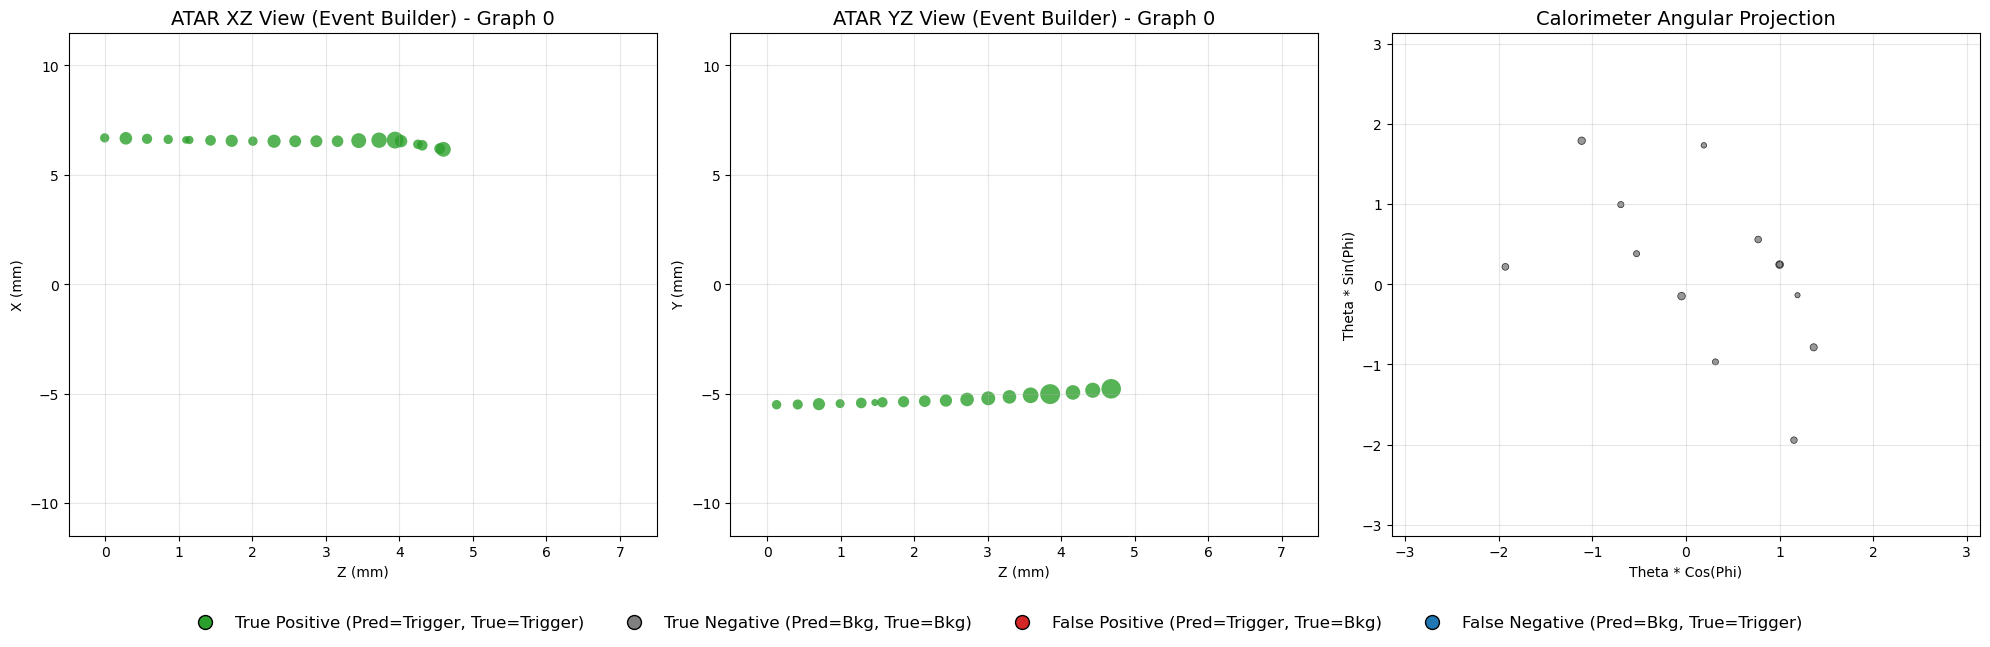

In [215]:
with torch.no_grad():
    batch = next(iter(dataloader)).to(device)
    targets = format_targets_from_batch(batch)
    outputs = model(batch.x, batch.batch)
    
    # Loop through any graphs you want!
    plot_event_builder_performance(batch, outputs, targets, g_idx=0)

In [119]:
def plot_effective_distance_from_highest_beta(batch, outputs, targets, g_idx=0, tau=1.0):
    is_lyso = (batch.x[:, 5] == 2)
    lyso_batch = batch.batch[is_lyso]
    local_lyso_mask = (lyso_batch == g_idx)
    
    if not local_lyso_mask.any():
        print(f"No LYSO hits in graph {g_idx}")
        return
        
    latent_coords = outputs['lyso_cluster_coords'][local_lyso_mask].detach().cpu().numpy()
    g_beta = outputs['lyso_beta'].squeeze(-1)[local_lyso_mask].detach().cpu().numpy()
    
    # Identify Radioactivity using the Fraction Target trick
    lyso_fracs = targets['tar_lyso_fracs']
    is_radio = (lyso_fracs.sum(dim=1) == 0.0)
    g_is_radio = is_radio[local_lyso_mask].detach().cpu().numpy()
    
    # Primary Seed
    max_beta_idx = np.argmax(g_beta)
    seed_latent = latent_coords[max_beta_idx]
    
    # 1. Raw Latent Distance
    raw_distances = np.sqrt(np.sum((latent_coords - seed_latent)**2, axis=1))
    
    # 2. Effective Latent Distance
    # We clip `g_beta` slightly above 0 strictly to prevent np.log(0) throwing an error
    safe_beta = np.clip(g_beta, 1e-5, 1.0)
    #effective_distances = raw_distances - (tau * np.log(safe_beta))
    effective_distances = raw_distances
    
    # Split into Radioactivity vs Physics
    radio_eff = effective_distances[g_is_radio]
    physics_eff = effective_distances[~g_is_radio]
    
    plt.figure(figsize=(10, 6))
    
    # Use tightly clustered bins to catch the runaway background
    bins = np.linspace(0, max(10.0, np.max(effective_distances)), 60)
    
    plt.hist([physics_eff, radio_eff], bins=bins,range=(0,5), stacked=False, 
             color=['#ff7f0e', 'gray'], label=['Signal & Trajectory Backgrounds', 'Intrinsic Radioactivity'],
             edgecolor='k', alpha=0.8)
    
    # Show exactly where the noise floor clamps down
    # noise_floor = 0.05 implies the cutoff effective distance is approx exactly tau * ln(1/0.05) ~ 3.0
    cutoff = -tau * np.log(0.05)
    plt.axvline(x=cutoff, color='red', linestyle='--', linewidth=2, label=f'Noise Floor Cutoff (d ~ {cutoff:.2f})')
    
    plt.title(f"Effective Spatial Distance from Primary LYSO Seed (Graph {g_idx})", fontsize=14)
    plt.xlabel("Effective Distance $d_{eff} = d - \\tau \ln(\\beta)$", fontsize=12)
    plt.ylabel("Number of LYSO Hits", fontsize=12)
    plt.legend(fontsize=11)
    
    # Hard limit the x-axis so the extreme beta=0 outliers don't crush the view
    plt.xlim(-0.2, 10)
    plt.grid(alpha=0.3)
    plt.show()

def plot_beta_distributions(batch, outputs, targets, g_idx=0):
    is_lyso = (batch.x[:, 5] == 2)
    lyso_batch = batch.batch[is_lyso]
    local_lyso_mask = (lyso_batch == g_idx)
    
    if not local_lyso_mask.any():
        print(f"No LYSO hits in graph {g_idx}")
        return
        
    # Extract predicted Beta scores
    g_beta = outputs['lyso_beta'].squeeze(-1)[local_lyso_mask].detach().cpu().numpy()
    
    # Identify Radioactivity
    lyso_fracs = targets['tar_lyso_fracs']
    is_radio = (lyso_fracs.sum(dim=1) == 0.0)
    g_is_radio = is_radio[local_lyso_mask].detach().cpu().numpy()
    
    # Split distributions
    radio_beta = g_beta[g_is_radio]
    physics_beta = g_beta[~g_is_radio]
    
    plt.figure(figsize=(10, 6))
    
    # Stacked Histogram
    plt.hist([physics_beta, radio_beta], bins=np.linspace(0, 1.0, 50), stacked=False, 
             color=['#ff7f0e', 'gray'], label=['Signal & Trajectory Backgrounds', 'Intrinsic Radioactivity'],
             edgecolor='k', alpha=0.8)
    
    plt.title(f"Predicted Beta Scores for Calorimeter Hits (Graph {g_idx})", fontsize=14)
    plt.xlabel("Predicted Condensation Score ($\\beta$)", fontsize=12)
    plt.ylabel("Number of LYSO Hits", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()

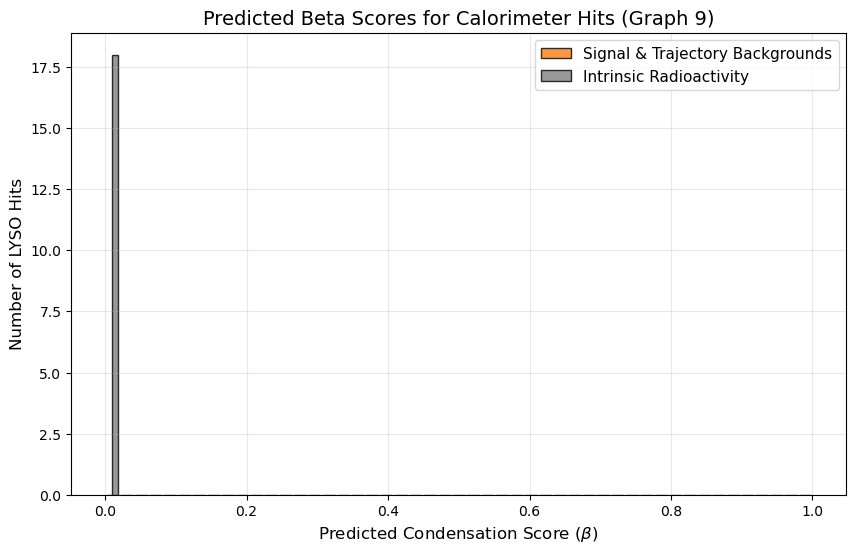

In [123]:
plot_beta_distributions(batch, outputs, targets, g_idx=9)

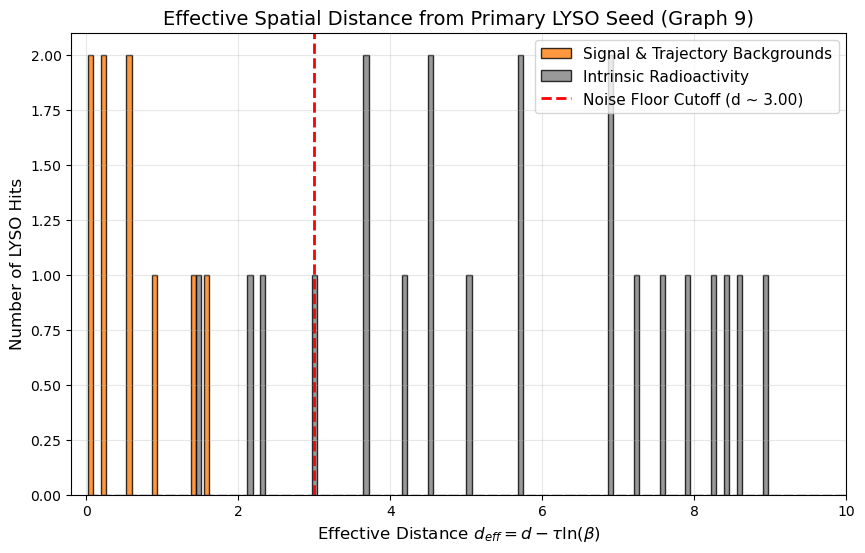

In [120]:
plot_effective_distance_from_highest_beta(batch, outputs, targets, g_idx=9)

In [101]:
def plot_calo_event_display(dataset_obj, model_obj, event_idx=0, threshold=0.5, dist_threshold=1.0):
    """
    Dual-panel calorimeter event display.
    Fixed: Legend marker sizes normalized. Radioactivity cannot form its own cluster.
    """
    # --- 1. Prepare Data and Model ---
    model_obj.train()
    device = next(model_obj.parameters()).device
    data = dataset_obj[event_idx]
    row = dataset_obj.df.iloc[event_idx]
    
    # --- 2. Forward Pass ---
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_lyso_condensation': 1.0})
    # --- 3. Filter for LYSO Hits ---
    is_lyso_mask = (batch.x[:, 5] == 2).cpu().numpy()
    if not is_lyso_mask.any():
        print(f"No LYSO hits found for event {event_idx}")
        return
    x_orig = batch.x[is_lyso_mask, 0].cpu().numpy() * 100.0
    y_orig = batch.x[is_lyso_mask, 1].cpu().numpy() * 100.0
    z_orig = batch.x[is_lyso_mask, 2].cpu().numpy() * 100.0
    energy = batch.x[is_lyso_mask, 3].cpu().numpy() * 70.0
    times = batch.x[is_lyso_mask, 4].cpu().numpy() * 500.0
    
    r = np.sqrt(x_orig**2 + y_orig**2 + z_orig**2)
    theta = np.arccos(np.clip(z_orig / r, -1.0, 1.0))
    phi = np.arctan2(y_orig, x_orig)
    
    proj_x = theta * np.sin(phi)
    proj_y = theta * np.cos(phi)
    marker_sizes = np.maximum(energy * 50.0, 5.0)
    
    # Extract True Origins for radioactivity masking
    lyso_origins = np.array(row.get('lyso_origin', np.zeros(len(x_orig))))
    # --- 4. Get True Clustering ---
    if hasattr(batch, 'lyso_fracs_target'):
        y_fracs = batch.lyso_fracs_target.cpu().numpy()
        if y_fracs.max() > 0:
            true_clusters = np.argmax(y_fracs, axis=1)
            true_clusters[y_fracs.sum(axis=1) < 0.1] = -1
        else:
            true_clusters = np.full(len(x_orig), -1)
    else:
        true_clusters = np.full(len(x_orig), -1)
    # --- 5. Get Predicted Clustering ---
    pred_clusters = np.full(len(x_orig), -1)
    
    if 'lyso_beta' in outputs:
        pred_beta = outputs['lyso_beta'].detach().cpu().numpy().flatten()
        pred_coords = outputs['lyso_cluster_coords'].detach().cpu().numpy()
        
        sort_idx = np.argsort(pred_beta)[::-1]
        alphas = []
        alpha_ids = []
        cluster_id = 0
        
        for i in sort_idx:
            if pred_beta[i] > threshold:
                # NEW: Do not let radioactivity hits become cluster centers (Alphas)
                if lyso_origins[i] == -1:
                    continue
                    
                is_new_alpha = True
                for a_coord in alphas:
                    if np.linalg.norm(pred_coords[i] - a_coord) < dist_threshold:
                        is_new_alpha = False
                        break
                
                if is_new_alpha:
                    alphas.append(pred_coords[i])
                    alpha_ids.append(cluster_id)
                    cluster_id += 1
            else:
                break
                
        if len(alphas) > 0:
            dists = cdist(pred_coords, np.array(alphas)) 
            min_dist_idx = np.argmin(dists, axis=1)       
            min_dists = np.min(dists, axis=1)             
            
            valid_assignment = min_dists < dist_threshold
            pred_clusters[valid_assignment] = np.array(alpha_ids)[min_dist_idx[valid_assignment]]
    # --- 6. Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
    cmap = plt.get_cmap('tab20')
    def draw_panel(ax, clusters, title):
        unique_ids = np.unique(clusters)
        handles, labels = [], []
        
        for i, cid in enumerate(unique_ids):
            mask = (clusters == cid)
            color = cmap(i % 20) if cid >= 0 else 'black'
            
            # --- New: Calculate Cluster Time ---
            if cid >= 0:
                t_avg = np.sum(times[mask] * energy[mask]) / np.sum(energy[mask])
                label = f'Cluster {cid} ({t_avg:.1f} ns)'
            else:
                label = 'Noise'
            
            # Plot the hits
            ax.scatter(proj_x[mask], proj_y[mask], s=marker_sizes[mask], 
                       color=color, alpha=0.7, edgecolors='black', linewidth=0.5)
            
            # Create legend entry
            dummy = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                               markeredgecolor='black', markersize=8, alpha=0.7)
            handles.append(dummy)
            labels.append(label)
        
        ax.set_title(title)
        ax.set_xlabel(r"$\theta \cdot \sin(\phi)$")
        ax.set_ylabel(r"$\theta \cdot \cos(\phi)$")
        ax.grid(alpha=0.3)
        ax.set_xlim(-np.pi, np.pi)
        ax.set_ylim(-np.pi, np.pi)
        
        # Draw legend and force all markers to have the same size (e.g., 20)
        ax.legend(handles, labels, loc='best', fontsize='xx-small', frameon=True, ncol=2)
        #for handle in leg.legend_handles:
        #    handle.set_sizes([20.0])
    draw_panel(axes[0], pred_clusters, f"Predicted Clustering (Event {event_idx})")
    draw_panel(axes[1], true_clusters, f"True Clustering (Event {event_idx})")
    plt.tight_layout()
    plt.show()

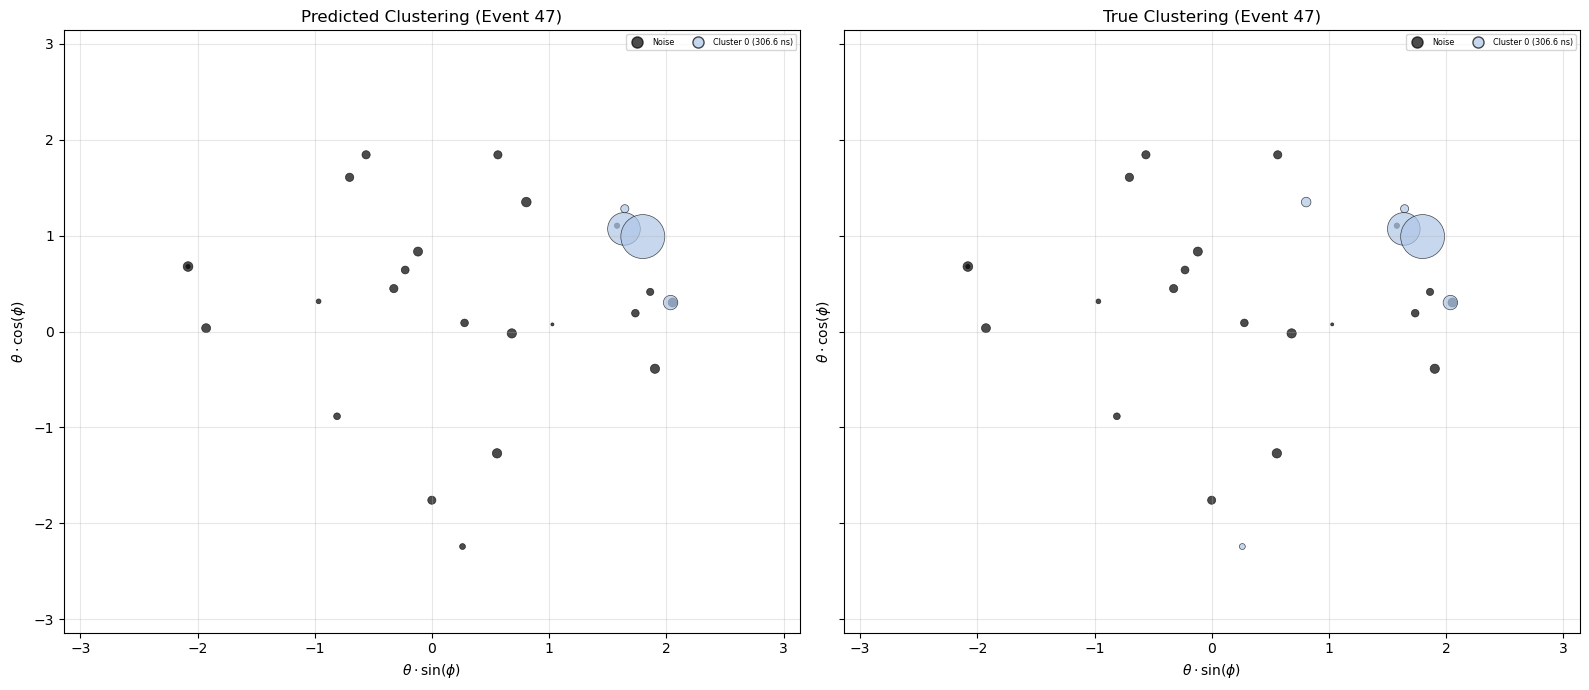

In [177]:
plot_calo_event_display(dataset, model, event_idx=47, threshold=0.5, dist_threshold=0.75)

In [37]:
def plot_hit_trigger_debug(dataset_obj, model_obj, event_idx=0, threshold=0.5):
    """
    Visualizes ATAR hits colored by hit-level Trigger Identification (Origin 0 vs Background).
    - Crimson: Correctly identified Trigger Hit (True Positive)
    - DodgerBlue: Correctly identified Background Hit (True Negative)
    - Black: Mistake (False Positive or False Negative)
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from torch_geometric.loader import DataLoader
    import numpy as np
    import torch
    
    model_obj.train()
    data = dataset_obj[event_idx]
    device = next(model_obj.parameters()).device
    
    # 1. Forward Pass
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        # Ensure trigger weight is ON
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_atar_hit_trigger': 1.0})
        targets = format_targets_from_batch(batch)
    if 'atar_hit_trigger' not in outputs:
        print("Model output did not contain 'atar_hit_trigger'. Check if w_atar_hit_trigger > 0.")
        return
    # 2. Extract Predictions and Targets (ATAR Hits only)
    pred_logits = outputs['atar_hit_trigger']
    pred_probs = torch.sigmoid(pred_logits).cpu().numpy()
    true_flags = targets['is_trigger'].cpu().numpy()
    
    pred_binary = (pred_probs > threshold).astype(float)
    is_correct = (pred_binary == true_flags)
    
    # 3. Geometry and Energy Extraction
    row = dataset_obj.df.iloc[event_idx]
    atar_x, atar_y, atar_z = np.array(row['atar_x']), np.array(row['atar_y']), np.array(row['atar_z'])
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_view = np.array(row['atar_view'])
    
    # Scale sizes based on Energy
    atar_s = np.clip(5 + atar_E * 150, 5, 500)
    
    # Define colors for each ATAR hit
    hit_colors = []
    for i in range(len(atar_x)):
        # Ensure we don't index out of bounds if shapes differ
        if i >= len(is_correct):
            hit_colors.append('lightgray')
            continue
            
        correct = is_correct[i]
        is_trigger_true = true_flags[i] > 0.5
        
        if correct and is_trigger_true:
            hit_colors.append('crimson')    # TP: Trigger Hit found
        elif correct and not is_trigger_true:
            hit_colors.append('dodgerblue') # TN: Background Hit confirmed
        else:
            hit_colors.append('black')      # Error (FP/FN)
            
    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Event {event_idx}: Hit-Level Trigger Identification (Marker Size = Energy)', fontsize=16)
    
    # --- XZ View ---
    mask_xz = (atar_view == 0)
    ax1.scatter(atar_z[mask_xz], atar_x[mask_xz], 
                c=[hit_colors[i] for i, m in enumerate(mask_xz) if m], 
                s=atar_s[mask_xz], alpha=0.7)
    ax1.set_title("X-Z View"); ax1.set_xlabel("Z [mm]"); ax1.set_ylabel("X [mm]")
    ax1.set_xlim(-0.5, 7.5); ax1.set_ylim(-11.5, 11.5); ax1.grid(True, linestyle='--', alpha=0.4)
    
    # --- YZ View ---
    mask_yz = (atar_view == 1)
    ax2.scatter(atar_z[mask_yz], atar_y[mask_yz], 
                c=[hit_colors[i] for i, m in enumerate(mask_yz) if m], 
                s=atar_s[mask_yz], alpha=0.7)
    ax2.set_title("Y-Z View"); ax2.set_xlabel("Z [mm]"); ax2.set_ylabel("Y [mm]")
    ax2.set_xlim(-0.5, 7.5); ax2.set_ylim(-11.5, 11.5); ax2.grid(True, linestyle='--', alpha=0.4)
    
    # Legend
    handles = [
        mpatches.Patch(color='crimson', label='Correct Trigger Hit (TP)'),
        mpatches.Patch(color='dodgerblue', label='Correct Pileup/Radio Hit (TN)'),
        mpatches.Patch(color='black', label='Prediction Error (FP/FN)')
    ]
    ax1.legend(handles=handles, loc='upper left')
    
    plt.tight_layout()
    plt.show()

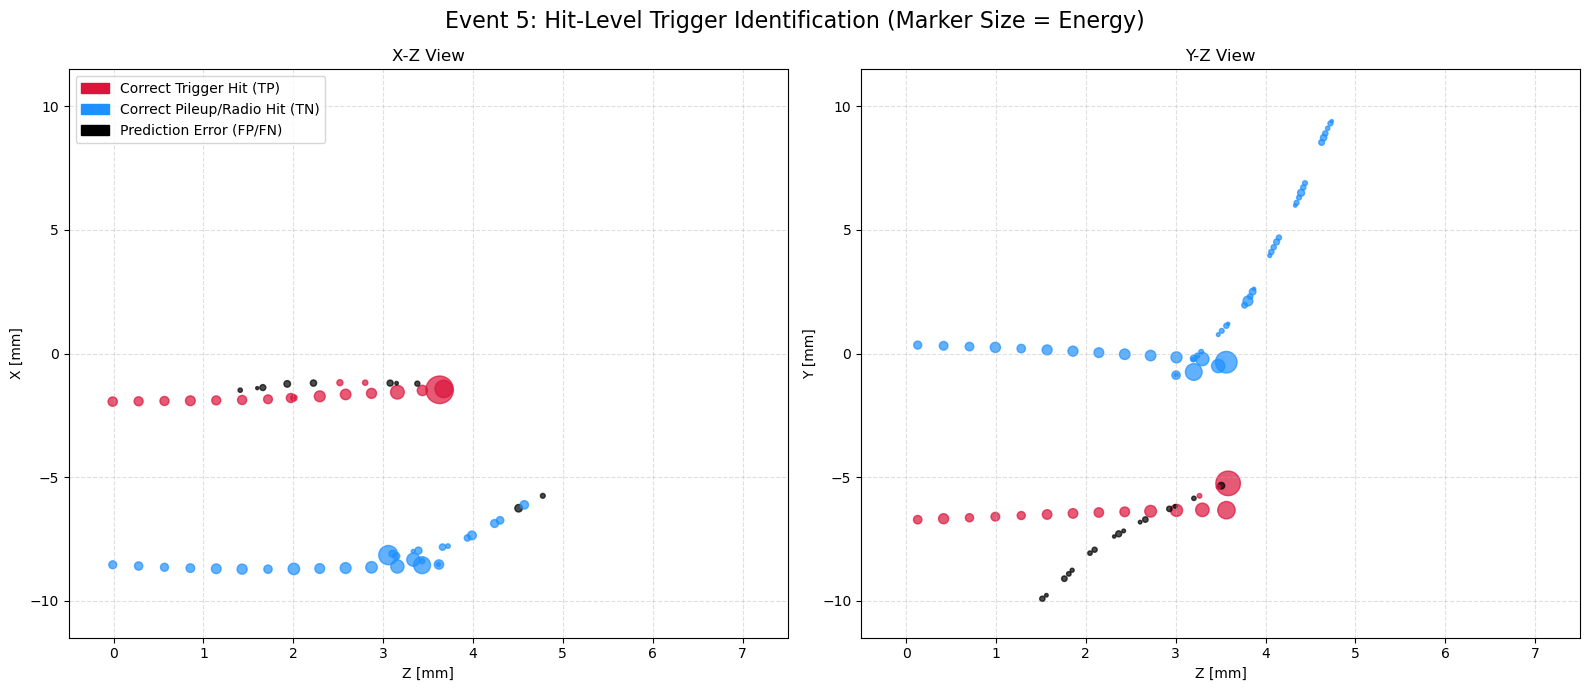

In [38]:
plot_hit_trigger_debug(dataset, model, event_idx=5)

In [39]:
def plot_multi_event_debug(dataset_obj, model_obj, event_idx=0, threshold=0.5):
    """
    Visualizes ATAR hits with marker sizes scaled by energy.
    - Crimson: Correctly identified pileup (True Positive)
    - DodgerBlue: Correctly identified single-event (True Negative)
    - Black: Mistake (False Positive or False Negative)
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from torch_geometric.loader import DataLoader
    import numpy as np
    import torch
    
    model_obj.train()
    data = dataset_obj[event_idx]
    device = next(model_obj.parameters()).device
    
    # 1. Forward Pass
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_atar_slice_multi': 1.0})
        targets = format_targets_from_batch(batch)
    if 'atar_slice_multi' not in outputs:
        print("Model output did not contain 'atar_slice_multi'. Check if w_atar_slice_multi > 0.")
        return
    # 2. Extract Predictions and Targets
    pred_logits = outputs['atar_slice_multi']
    pred_probs = torch.sigmoid(pred_logits).cpu().numpy()
    true_flags = targets['atar_slice_multi_target'].cpu().numpy()
    
    # Align lengths if model filters slices
    if len(true_flags) > len(pred_probs):
        true_flags = true_flags[:len(pred_probs)] 
    
    pred_binary = (pred_probs > threshold).astype(float)
    is_correct = (pred_binary == true_flags)
    
    # 3. Geometry and Energy Extraction
    row = dataset_obj.df.iloc[event_idx]
    atar_x, atar_y, atar_z = np.array(row['atar_x']), np.array(row['atar_y']), np.array(row['atar_z'])
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_view = np.array(row['atar_view'])
    atar_slice = np.array(row['atar_slice'])
    unique_slices = np.unique(atar_slice)[:len(pred_probs)]
    
    # Scale sizes based on Energy (from your original logic)
    atar_s = np.clip(5 + atar_E * 150, 5, 500)
    
    # Map slice results to hit colors
    hit_colors = []
    for s in atar_slice:
        s_matches = np.where(unique_slices == s)[0]
        if len(s_matches) == 0:
            hit_colors.append('lightgray')
            continue
        
        s_idx = s_matches[0]
        correct = is_correct[s_idx]
        is_multi = true_flags[s_idx] > 0.5
        
        if correct and is_multi:
            hit_colors.append('crimson')
        elif correct and not is_multi:
            hit_colors.append('dodgerblue')
        else:
            hit_colors.append('black')
            
    # 4. Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))
    fig.suptitle(f'Event {event_idx}: Multi-Event Tagger Debug (Marker Size = Energy)', fontsize=16)
    
    # --- XZ View ---
    mask_xz = (atar_view == 0)
    ax1.scatter(atar_z[mask_xz], atar_x[mask_xz], 
                c=[hit_colors[i] for i, m in enumerate(mask_xz) if m], 
                s=atar_s[mask_xz], alpha=0.7)
    ax1.set_title("X-Z View"); ax1.set_xlabel("Z [mm]"); ax1.set_ylabel("X [mm]")
    ax1.set_xlim(-0.5, 7.5); ax1.set_ylim(-11.5, 11.5); ax1.grid(True, linestyle='--', alpha=0.4)
    
    # --- YZ View ---
    mask_yz = (atar_view == 1)
    ax2.scatter(atar_z[mask_yz], atar_y[mask_yz], 
                c=[hit_colors[i] for i, m in enumerate(mask_yz) if m], 
                s=atar_s[mask_yz], alpha=0.7)
    ax2.set_title("Y-Z View"); ax2.set_xlabel("Z [mm]"); ax2.set_ylabel("Y [mm]")
    ax2.set_xlim(-0.5, 7.5); ax2.set_ylim(-11.5, 11.5); ax2.grid(True, linestyle='--', alpha=0.4)
    
    # --- Score Chart ---
    ax3.bar(range(len(pred_probs)), pred_probs, color='gray', alpha=0.3, label='Pred Probability')
    ax3.scatter(range(len(true_flags)), true_flags, color='red', marker='x', s=60, label='True Flag')
    ax3.axhline(threshold, color='black', linestyle='--', alpha=0.4, label='Threshold')
    ax3.set_title("Slice Scores"); ax3.set_xlabel("Slice Index"); ax3.set_ylabel("Prob")
    ax3.set_ylim(-0.05, 1.05); ax3.legend()
    
    # Legend
    handles = [
        mpatches.Patch(color='crimson', label='Correct Pileup (TP)'),
        mpatches.Patch(color='dodgerblue', label='Correct Signal (TN)'),
        mpatches.Patch(color='black', label='Error (FP/FN)')
    ]
    ax1.legend(handles=handles, loc='upper left')
    
    plt.tight_layout()
    plt.show()
# Usage:
# plot_multi_event_debug(dataset, model, event_idx=5)

In [16]:
failure_indices = []
threshold = 0.5
num_to_scan = 2000  # Number of events to check
model.eval()
with torch.no_grad():
    print(f"Scanning first {num_to_scan} events for failures...")
    for i in tqdm(range(min(len(dataset), num_to_scan))):
        data = dataset[i]
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        
        # Ensure the head is active
        outputs = model(batch.x, batch.batch, task_weights={'w_atar_slice_multi': 1.0})
        targets = format_targets_from_batch(batch)
        
        if 'atar_slice_multi' in outputs:
            pred_probs = torch.sigmoid(outputs['atar_slice_multi'])
            pred_binary = (pred_probs > threshold).float()
            true_flags = targets['atar_slice_multi_target']
            
            # Align lengths if the model filters slices (stereo-only mode)
            true_flags = true_flags[:pred_binary.shape[0]]
            
            # If any slice in the event is wrong, record the index
            if not torch.equal(pred_binary, true_flags):
                failure_indices.append(i)
print(f"Done. Found {len(failure_indices)} failure events.")
print("Indices to inspect:", failure_indices)

Scanning first 2000 events for failures...


100%|██████████| 2000/2000 [00:42<00:00, 47.28it/s]

Done. Found 87 failure events.
Indices to inspect: [79, 93, 112, 147, 191, 211, 237, 269, 299, 335, 373, 404, 406, 416, 449, 466, 471, 481, 487, 492, 573, 603, 621, 652, 671, 674, 753, 757, 767, 796, 814, 820, 850, 862, 871, 894, 928, 986, 995, 998, 1011, 1018, 1026, 1048, 1079, 1091, 1130, 1132, 1180, 1197, 1200, 1217, 1264, 1266, 1281, 1282, 1306, 1311, 1333, 1345, 1352, 1356, 1374, 1448, 1504, 1554, 1574, 1587, 1618, 1660, 1671, 1703, 1708, 1727, 1739, 1759, 1791, 1798, 1804, 1837, 1863, 1864, 1888, 1897, 1952, 1976, 1993]


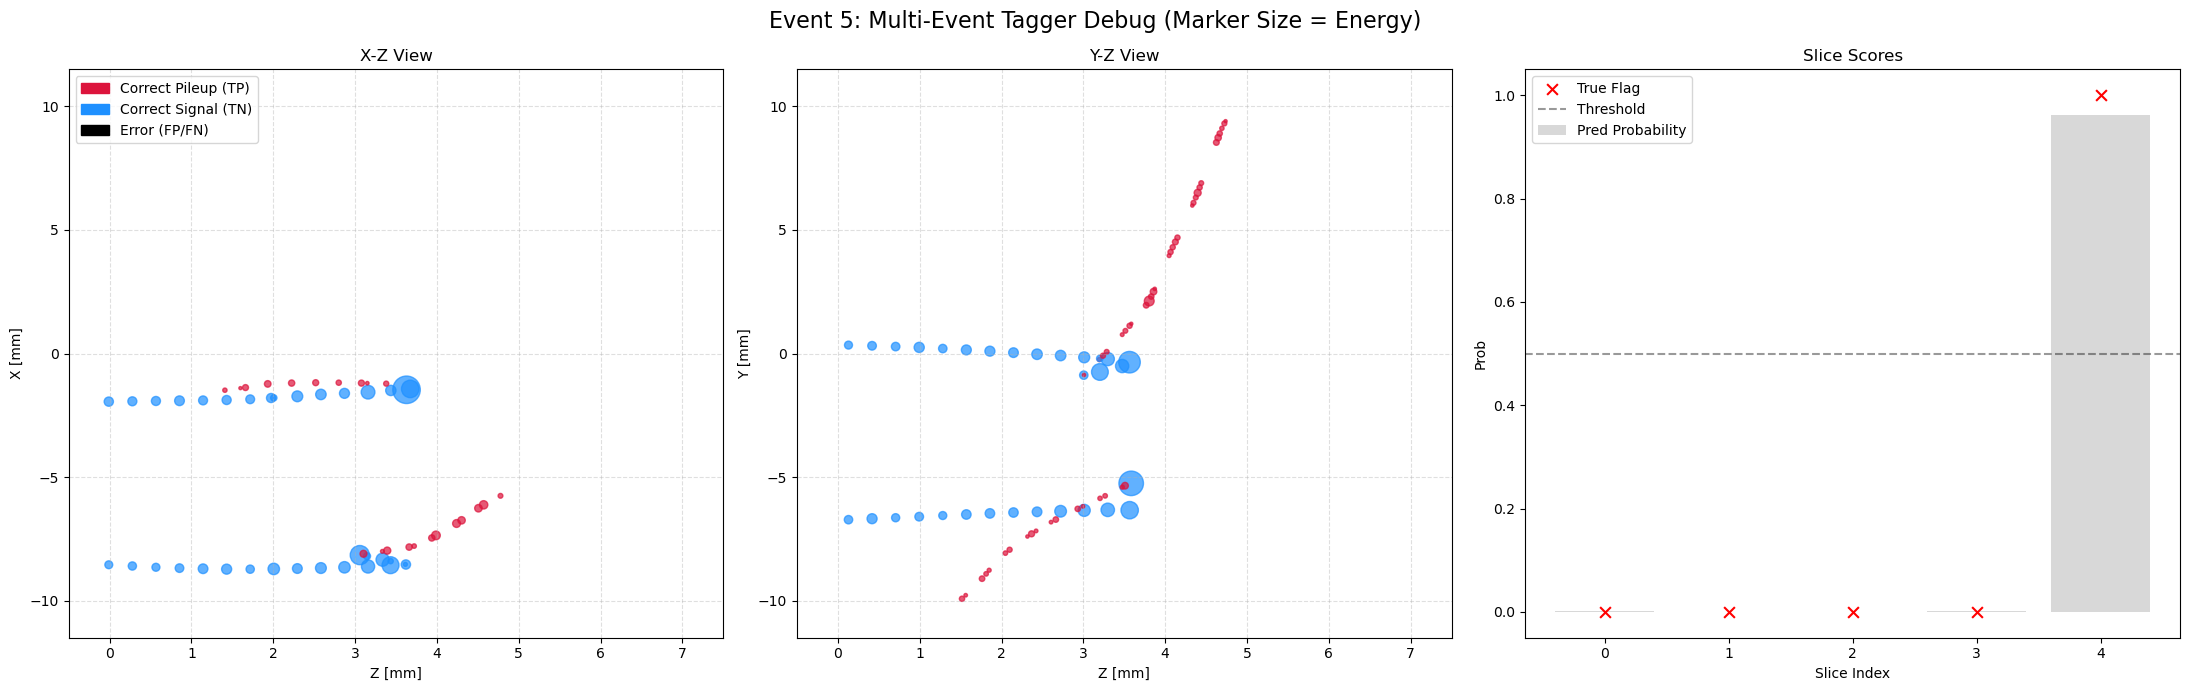

In [40]:
plot_multi_event_debug(dataset, model, event_idx=5)

In [9]:
def plot_endpoints_debug(dataset_obj, model_obj, event_idx=0):
    model_obj.train()
    data = dataset_obj[event_idx]
    
    # 1. Forward Pass
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_node_pdg': 1.0, 'w_endpoints': 1.0})
        targets = format_targets_from_batch(batch)
    
    # 2. Geometry Extraction
    row = dataset_obj.df.iloc[event_idx]
    atar_x, atar_y, atar_z = np.array(row['atar_x']), np.array(row['atar_y']), np.array(row['atar_z'])
    atar_view = np.array(row['atar_view'])
    
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_s = np.clip(20 + atar_E * 150, 1, 500)
    
    # 3. Validation Check
    num_slices = len(targets.get('tar_slice_start_x', []))
    if num_slices == 0:
        print("No endpoint targets generated for this event.")
        return
        
    if 'atar_endpoints' not in outputs or len(outputs['atar_endpoints']) == 0:
        print("Model failed to output any endpoints.")
        return
        
    # 4. Node Splitting Prediction (For Graph Coloring)
    pred_node_classes = torch.argmax(outputs['atar_node_pdg'], dim=1).cpu().numpy()
    color_map = {0: 'red', 1: 'blue', 2: 'green'} # Pion=Red, Muon=Blue, MIP=Green
    hit_colors = [color_map[c] for c in pred_node_classes]
    
    handles = [
        mpatches.Patch(color='red', label='Pred Pion'),
        mpatches.Patch(color='blue', label='Pred Muon'),
        mpatches.Patch(color='green', label='Pred MIP')
    ]
    
    # 5. Plot XZ and YZ views
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Event {event_idx} ATAR Endpoint Regression ({num_slices} Tracks)', fontsize=16)
    
    # --- XZ Projection ---
    mask_xz = (atar_view == 0)
    colors_xz = [hit_colors[i] for i, m in enumerate(mask_xz) if m]
    sizes_xz = atar_s[mask_xz]
    ax1.scatter(atar_z[mask_xz], atar_x[mask_xz], c=colors_xz, s=sizes_xz, alpha=0.7, edgecolors='none', label='ATAR Hits')
    
    # --- YZ Projection ---
    mask_yz = (atar_view == 1)
    colors_yz = [hit_colors[i] for i, m in enumerate(mask_yz) if m]
    sizes_yz = atar_s[mask_yz]
    ax2.scatter(atar_z[mask_yz], atar_y[mask_yz], c=colors_yz, s=sizes_yz, alpha=0.7, edgecolors='none', label='ATAR Hits')
    
    # --- Loop Over All Tracks ---
    for s in range(num_slices):
        true_start_x, true_start_y, true_start_z = targets['tar_slice_start_x'][s].item(), targets['tar_slice_start_y'][s].item(), targets['tar_slice_start_z'][s].item()
        true_stop_x, true_stop_y, true_stop_z = targets['tar_slice_stop_x'][s].item(), targets['tar_slice_stop_y'][s].item(), targets['tar_slice_stop_z'][s].item()
        
        pred_start_x = outputs['atar_endpoints'][s, 0, 0, 1].item() * 10.0
        pred_start_y = outputs['atar_endpoints'][s, 0, 1, 1].item() * 10.0
        pred_start_z = outputs['atar_endpoints'][s, 0, 2, 1].item() * 10.0
        
        pred_stop_x = outputs['atar_endpoints'][s, 1, 0, 1].item() * 10.0
        pred_stop_y = outputs['atar_endpoints'][s, 1, 1, 1].item() * 10.0
        pred_stop_z = outputs['atar_endpoints'][s, 1, 2, 1].item() * 10.0
        # Only label the very first slice so we don't spam the legend
        t_label_start = 'True Start' if s == 0 else None
        t_label_stop = 'True Stop' if s == 0 else None
        p_label_start = 'Pred Start' if s == 0 else None
        p_label_stop = 'Pred Stop' if s == 0 else None
        # XZ
        ax1.scatter([true_start_z*10], [true_start_x*10], c='limegreen', marker='x', s=100, label=t_label_start)
        ax1.scatter([true_stop_z*10], [true_stop_x*10], c='limegreen', marker='x', s=100, label=t_label_stop)
        ax1.scatter([pred_start_z], [pred_start_x], c='black', marker='x', s=100, linewidth=1, label=p_label_start)
        ax1.scatter([pred_stop_z], [pred_stop_x], c='black', marker='x', s=100, linewidth=1, label=p_label_stop)
        ax1.plot([true_start_z*10, true_stop_z*10], [true_start_x*10, true_stop_x*10], c='limegreen', linestyle='--', alpha=0.8)
        ax1.plot([pred_start_z, pred_stop_z], [pred_start_x, pred_stop_x], c='black', linestyle=':', alpha=0.8)
        # YZ
        ax2.scatter([true_start_z*10], [true_start_y*10], c='limegreen', marker='x', s=100, label=t_label_start)
        ax2.scatter([true_stop_z*10], [true_stop_y*10], c='limegreen', marker='x', s=100, label=t_label_stop)
        ax2.scatter([pred_start_z], [pred_start_y], c='black', marker='x', s=100, linewidth=1, label=p_label_start)
        ax2.scatter([pred_stop_z], [pred_stop_y], c='black', marker='x', s=100, linewidth=1, label=p_label_stop)
        ax2.plot([true_start_z*10, true_stop_z*10], [true_start_y*10, true_stop_y*10], c='limegreen', linestyle='--', alpha=0.8)
        ax2.plot([pred_start_z, pred_stop_z], [pred_start_y, pred_stop_y], c='black', linestyle=':', alpha=0.8)

        print(true_start_z*10, true_stop_z*10, pred_start_z, pred_stop_z)
    
    ax1.set_xlabel('Z [mm]'); ax1.set_ylabel('X [mm]')
    ax1.set_xlim(-0.5, 7.5); ax1.set_ylim(-13.5, 13.5)
    ax1.yaxis.set_major_locator(MultipleLocator(2.5))
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(handles=handles + ax1.get_legend_handles_labels()[0][1:])
    ax1.set_title("X-Z Projection")
    
    ax2.set_xlabel('Z [mm]'); ax2.set_ylabel('Y [mm]')
    ax2.set_xlim(-0.5, 7.5); ax2.set_ylim(-13.5, 13.5)
    ax2.yaxis.set_major_locator(MultipleLocator(2.5))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(handles=handles + ax2.get_legend_handles_labels()[0][1:])
    ax2.set_title("Y-Z Projection")
    
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_trigger_debug(dataset_obj, model_obj, event_idx=0):
    """
    Visualize which ATAR hits are identified as part of the triggering event
    by the label propagation trigger mask.
    
    Hit opacity/color = predicted trigger probability (1=trigger, 0=background).
    Ground truth trigger hits (atar_true_event_id == 0) outlined in gold.
    """
    model_obj.train()
    data = dataset_obj[event_idx]
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        outputs = model_obj(batch.x, batch.batch,
                            task_weights={'w_node_pdg': 1.0, 'w_endpoints': 1.0, 'w_atar_edge': 1.0})
    # ── Raw hit coordinates from dataset ──────────────────────────────────
    row      = dataset_obj.df.iloc[event_idx]
    atar_x   = np.array(row['atar_x'])
    atar_y   = np.array(row['atar_y'])
    atar_z   = np.array(row['atar_z'])
    atar_view = np.array(row['atar_view'])
    atar_E   = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_s   = np.clip(20 + atar_E * 150, 1, 500)
    if len(atar_x) == 0:
        print("No ATAR hits in this event.")
        return
    # ── Predicted trigger probability per ATAR hit ─────────────────────────
    pred_trigger = outputs['atar_hit_trigger'].cpu().numpy()  # [N_atar]
    # ── Ground truth: event_id == 0 → triggering event ────────────────────
    has_gt = hasattr(batch, 'atar_true_event_id')
    if has_gt:
        gt_trigger = (batch.atar_true_event_id.cpu().numpy() == 0)  # [N_atar]
    # ── Separate views ─────────────────────────────────────────────────────
    mask_xz = (atar_view == 0)
    mask_yz = (atar_view == 1)
    # hit_colors for PDG node classes (same as plot_endpoints_debug)
    pred_node_classes = torch.argmax(outputs['atar_node_pdg'], dim=1).cpu().numpy()
    color_map = {0: 'red', 1: 'blue', 2: 'green'}
    hit_colors = np.array([color_map[c] for c in pred_node_classes])
    # ── Figure ─────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Event {event_idx}  —  ATAR Trigger Identification', fontsize=16)
    def draw_view(ax, z_vals, coord_vals, view_mask, xlabel, ylabel, title):
        z_v    = z_vals[view_mask]
        c_v    = coord_vals[view_mask]
        s_v    = atar_s[view_mask]
        tr_v   = pred_trigger[view_mask]
        col_v  = hit_colors[view_mask]
        # 1. All hits — size and PDG color preserved, alpha = trigger probability
        for i in range(len(z_v)):
            ax.scatter(z_v[i], c_v[i], s=s_v[i],
                       color=col_v[i], alpha=float(tr_v[i]) * 0.85 + 0.1,
                       edgecolors='none', zorder=2)
        # 2. Ground-truth trigger hits — gold outline ring
        if has_gt:
            gt_v = gt_trigger[view_mask]
            ax.scatter(z_v[gt_v], c_v[gt_v], s=s_v[gt_v] + 20,
                       facecolors='none', edgecolors='gold', linewidths=1.5,
                       label='GT Trigger', zorder=3)
            ax.scatter(z_v[~gt_v], c_v[~gt_v], s=s_v[~gt_v] + 20,
                       facecolors='none', edgecolors='#888888', linewidths=0.6,
                       alpha=0.4, label='GT Background', zorder=3)
        # 3. Colorbar proxy for trigger probability
        sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label='Pred trigger prob', fraction=0.03, pad=0.02)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_xlim(-0.5, 7.5); ax.set_ylim(-13.5, 13.5)
        ax.yaxis.set_major_locator(MultipleLocator(2.5))
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_title(title)
        handles = [
            mpatches.Patch(color='red',   label='Pred Pion'),
            mpatches.Patch(color='blue',  label='Pred Muon'),
            mpatches.Patch(color='green', label='Pred MIP'),
        ] + ax.get_legend_handles_labels()[0]
        ax.legend(handles=handles, fontsize=8)

    atar_in_batch = (batch.x[:, 5] == 0.0) | (batch.x[:, 5] == 1.0)
    ev_id = batch.atar_true_event_id  # 0 = trigger, 1+ = pileup
    trigger_hits = outputs['atar_hit_trigger'][ev_id == 0]
    pileup_hits  = outputs['atar_hit_trigger'][ev_id != 0]
    print(f"Trigger hits  →  pred prob: {trigger_hits}")
    print(f"Trigger hits  → mean pred prob: {trigger_hits.mean():.3f}")
    print(f"Pileup hits   → mean pred prob: {pileup_hits.mean():.3f}")
    draw_view(ax1, atar_z, atar_x, mask_xz, 'Z [mm]', 'X [mm]', 'X-Z Projection')
    draw_view(ax2, atar_z, atar_y, mask_yz, 'Z [mm]', 'Y [mm]', 'Y-Z Projection')
    plt.tight_layout()
    plt.show()

-0.009500000160187483 3.511105179786682 -0.027775680646300316 3.552638590335846
2.968156635761261 3.4655001759529114 2.7368542551994324 4.17327493429184
2.916480004787445 4.820652604103088 2.7167198061943054 4.5452916622161865


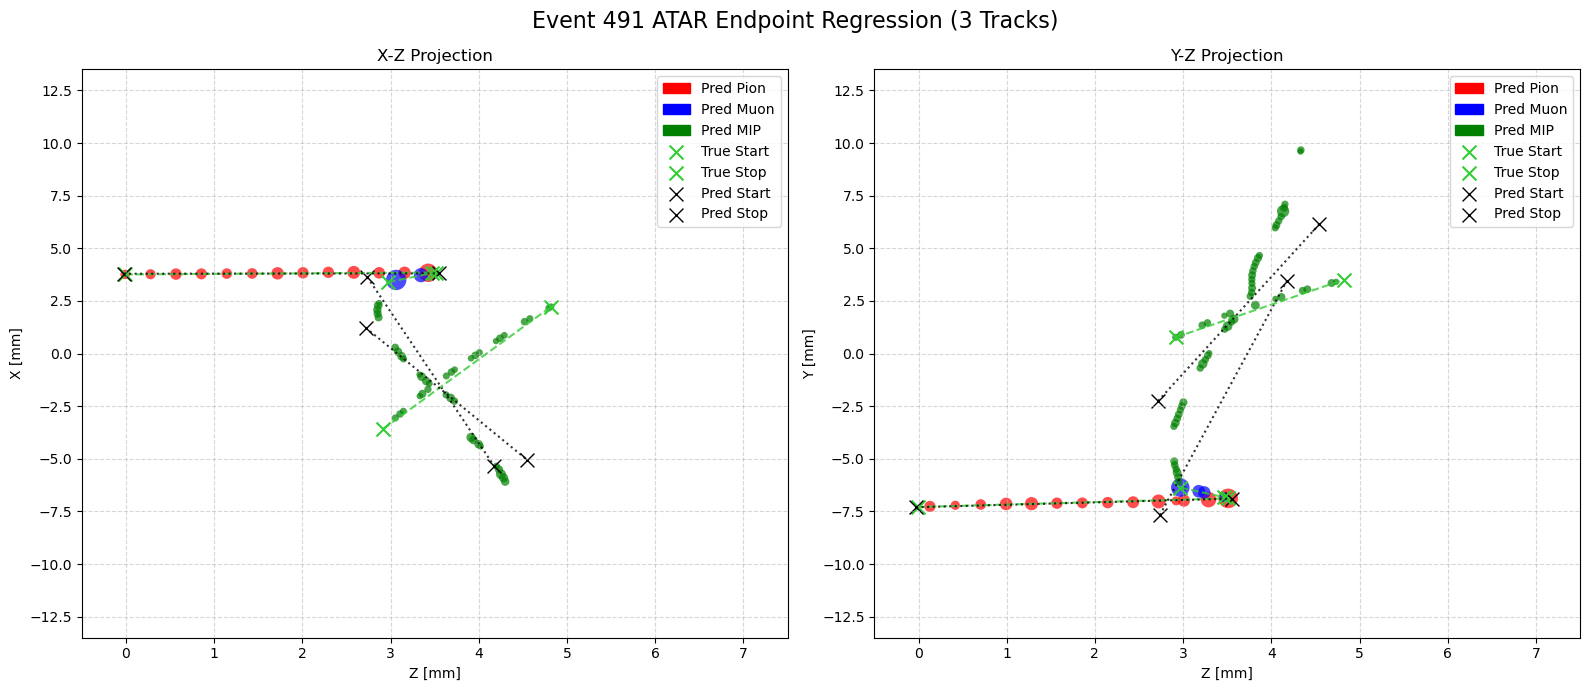

In [84]:
plot_endpoints_debug(dataset, model, event_idx=491)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
Trigger hits  →  pred prob: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')
Trigger hits  → mean pred prob: 

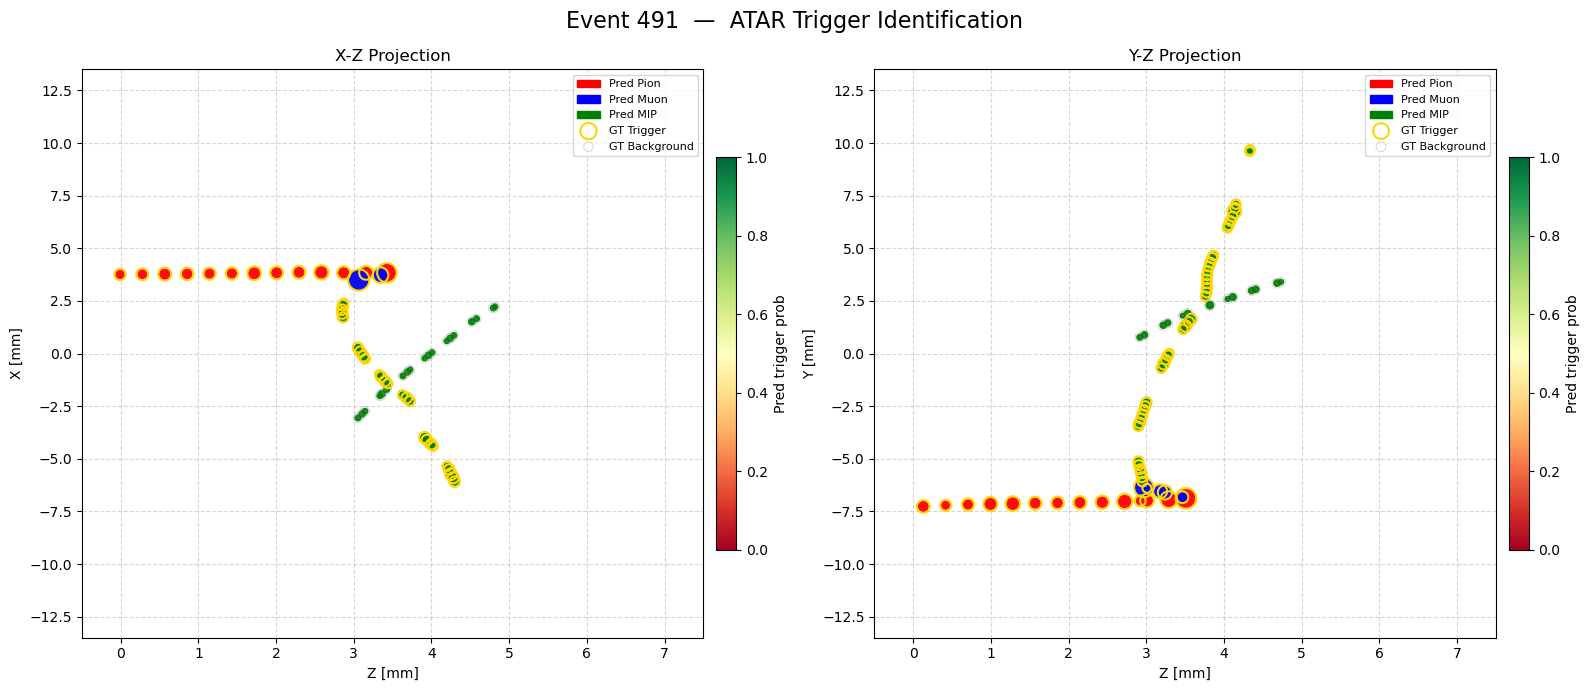

In [85]:
plot_trigger_debug(dataset, model, event_idx=491)

In [73]:
def investigate_pdg_at_index(dataset_obj, model_obj, event_idx=0, device='cuda'):
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
    from torch_geometric.data import Batch  # Import Batch to fix the NoneType error
    # 1. Prepare Data as a Batch of 1
    model_obj.eval()
    data = dataset_obj[event_idx]
    batch = Batch.from_data_list([data]).to(device) # This adds the .batch attribute
    
    # 2. Forward Pass
    with torch.no_grad():
        outputs = model_obj(batch.x, batch.batch)
        # Now it's compatible with your standard formatting function
        targets = format_targets_from_batch(batch) 
    # 3. Extract Statistics
    pred_probs = torch.sigmoid(outputs['atar_slice_pdg']).cpu().numpy()
    true_targets = targets['tar_slice_pdg'].cpu().numpy()
    valid_slice_mask = outputs['valid_slice_mask'].cpu().numpy()
    num_slices_max = outputs['num_slices_max']
    
    valid_indices = np.where(valid_slice_mask)[0]
    # 4. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    cmap = plt.get_cmap('tab20')
    
    is_atar = (batch.x[:, 5] == 0) | (batch.x[:, 5] == 1)
    g_atar_x = batch.x[is_atar, 0].cpu().numpy() * 10
    g_atar_y = batch.x[is_atar, 1].cpu().numpy() * 10
    g_atar_z = batch.x[is_atar, 2].cpu().numpy() * 10 
    g_atar_e = batch.x[is_atar, 3].cpu().numpy()
    g_atar_view = batch.x[is_atar, 5].cpu().numpy() 
    g_atar_slice = batch.x[is_atar, 6].cpu().numpy().astype(int)
    for i, view_name in enumerate(["XZ", "YZ"]):
        ax = axes[i]
        mask_view = (g_atar_view == i)
        ax.scatter(g_atar_z[mask_view], 
                   g_atar_x[mask_view] if i == 0 else g_atar_y[mask_view], 
                   c=g_atar_slice[mask_view], 
                   cmap=cmap, s=g_atar_e[mask_view]*200+20, 
                   alpha=0.8, edgecolors='black', linewidth=0.5)
        
        ax.set_title(f"{view_name} View (Event {event_idx})")
        ax.set_xlim(-0.5, 7.5); ax.set_ylim(-11.5, 11.5)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # 5. Table Output
    print(f"\n--- PDG Target Investigation (Event {event_idx}) ---")
    print(f"{'Slice':<8} | {'Type':<10} | {'True Target':<18} | {'Pred Prob (Pi, Mu, MIP)':<25}")
    print("-" * 75)
    
    class_names = ["Pion", "Muon", "MIP"]
    for local_idx in range(len(valid_indices)):
        t = true_targets[local_idx]
        p = pred_probs[local_idx]
        true_types = [class_names[i] for i, val in enumerate(t) if val > 0.5]
        true_type_str = "+".join(true_types) if true_types else "None"
        
        print(f"{local_idx:<8} | {true_type_str:<10} | {str(t):<18} | ({p[0]:.3f}, {p[1]:.3f}, {p[2]:.3f})")

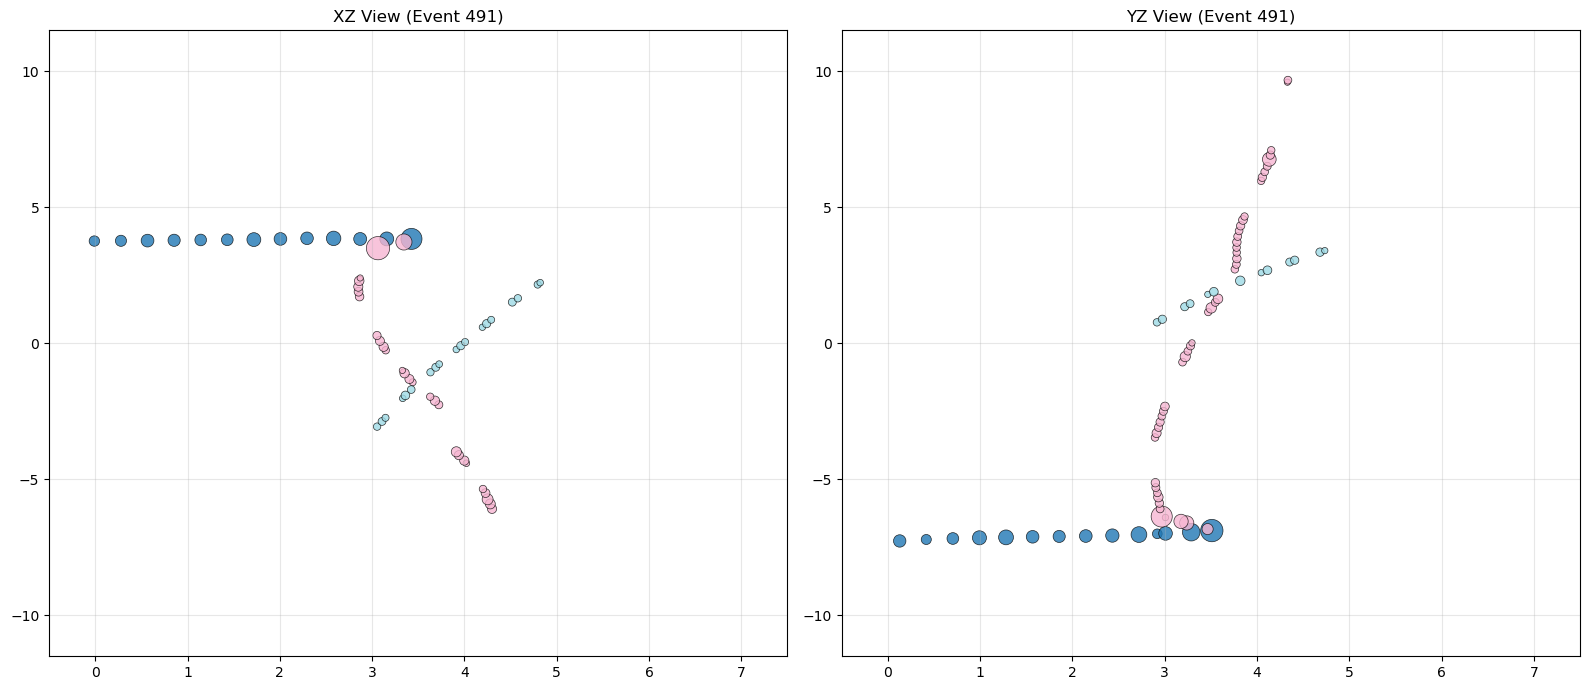


--- PDG Target Investigation (Event 491) ---
Slice    | Type       | True Target        | Pred Prob (Pi, Mu, MIP)  
---------------------------------------------------------------------------
0        | Pion       | [1. 0. 0.]         | (1.000, 0.008, 0.000)
1        | Muon+MIP   | [0. 1. 1.]         | (0.000, 0.227, 1.000)
2        | MIP        | [0. 0. 1.]         | (0.000, 0.000, 1.000)


In [83]:
investigate_pdg_at_index(dataset, model, event_idx=491)

In [76]:
def scan_pdg_errors(dataset_obj, model_obj, num_events=5000, device='cuda'):
    import torch
    from torch_geometric.data import Batch
    from tqdm import tqdm
    import numpy as np
    model_obj.train()
    error_indices = []
    
    # Track error counts
    # (True Class -> Pred Class)
    class_names = ["Pion", "Muon", "MIP"]
    confusion_matrix = np.zeros((3, 3), dtype=int)
    
    print(f"Scanning first {num_events} events for PDG classification errors...")
    
    for i in tqdm(range(num_events)):
        data = dataset_obj[i]
        batch = Batch.from_data_list([data]).to(device)
        
        with torch.no_grad():
            outputs = model_obj(batch.x, batch.batch)
            targets = format_targets_from_batch(batch)
            
            # Extract valid slice targets and predictions
            t_pdg = targets['tar_slice_pdg'].cpu().numpy()
            p_logits = outputs['atar_slice_pdg'].cpu()
            p_probs = torch.sigmoid(p_logits).numpy()
            
        # Check every valid slice in this event
        has_error = False
        for local_idx in range(len(t_pdg)):
            true_bits = t_pdg[local_idx]
            pred_bits = p_probs[local_idx]
            
            if np.max(true_bits) < 0.5: continue # Skip slices with no ground truth
            
            t_class = np.argmax(true_bits)
            p_class = np.argmax(pred_bits)
            
            # Simple mismatch check
            if t_class != p_class:
                confusion_matrix[t_class, p_class] += 1
                has_error = True
        
        if has_error:
            error_indices.append(i)
    # Summary
    print("\n--- Diagnostic Results ---")
    print(f"Total Events Scanned: {num_events}")
    print(f"Events with at least 1 PDG error: {len(error_indices)} ({len(error_indices)/num_events*100:.2f}%)")
    
    print("\nConfusion Matrix (True \ Pred):")
    print(f"{'':<10} | {'Pion':<8} | {'Muon':<8} | {'MIP':<8}")
    print("-" * 45)
    for i in range(3):
        print(f"{class_names[i]:<10} | {confusion_matrix[i,0]:<8} | {confusion_matrix[i,1]:<8} | {confusion_matrix[i,2]:<8}")
    # Display some problematic indices for you to visualize
    if error_indices:
        print(f"\nExample Problematic Indices: {error_indices[:15]}...")
    
    return error_indices

In [77]:
problem_ids = scan_pdg_errors(dataset, model, num_events=5000)

Scanning first 5000 events for PDG classification errors...


100%|██████████| 5000/5000 [03:03<00:00, 27.27it/s]


--- Diagnostic Results ---
Total Events Scanned: 5000
Events with at least 1 PDG error: 29 (0.58%)

Confusion Matrix (True \ Pred):
           | Pion     | Muon     | MIP     
---------------------------------------------
Pion       | 0        | 5        | 1       
Muon       | 4        | 0        | 19      
MIP        | 0        | 0        | 0       

Example Problematic Indices: [122, 346, 491, 941, 1170, 1238, 1262, 1266, 1304, 1484, 1597, 1834, 1974, 2199, 2299]...


In [ ]:
def plot_pion_kinematics_debug(dataset_obj, model_obj, event_idx=0):
    model_obj.train()
    data = dataset_obj[event_idx]
    
    # 1. Forward Pass
    with torch.no_grad():
        loader = DataLoader([data], batch_size=1)
        batch = next(iter(loader)).to(device)
        # Turn ON Node PDG so we can color the graph
        outputs = model_obj(batch.x, batch.batch, task_weights={'w_node_pdg': 1.0, 'w_pion_kinematics': 0.01, 'w_slice_pdg': 1.0})
    
    # 2. Geometry Extraction
    row = dataset_obj.df.iloc[event_idx]
    atar_x, atar_y, atar_z = np.array(row['atar_x']), np.array(row['atar_y']), np.array(row['atar_z'])
    atar_view = np.array(row['atar_view'])
    
    # Scale ATAR energy for point size. Base size is 20, scaling up linearly with E
    atar_E = np.array(row['atar_E']) if 'atar_E' in row else np.zeros_like(atar_x)
    atar_s = np.clip(20 + atar_E * 150, 1, 500)
    pred_slice_pdg = torch.sigmoid(outputs['atar_slice_pdg'])
    print(pred_slice_pdg)
    
    # 3. True Kinematics
    true_x = row.get('truth_pion_stop_x', 0.0)
    true_y = row.get('truth_pion_stop_y', 0.0)
    true_z = row.get('truth_pion_stop_z', 0.0)
    
    # 4. Predicted Kinematics (Find highest-probability Pion slice)
    if 'atar_slice_pdg' in outputs and len(outputs['atar_slice_pdg']) > 0:
        pion_probs = torch.sigmoid(outputs['atar_slice_pdg'][:, 0])
        best_pion_idx = torch.argmax(pion_probs).item()r_pion_stop_y'][best_pion_idx].item() * 10.0
        pred_z = outputs['atar_pion_stop_z'][best_pion_idx].item() * 10.0
    else:
        print("Model failed to output any slices.")
        return
        
    # 5. Node Splitting Prediction (For Graph Coloring)
    # Target space is [Pion, Muon, MIP]. Argmax returns 0, 1, or 2.
    pred_node_classes = torch.argmax(outputs['atar_node_pdg'], dim=1).cpu().numpy()
    
    color_map = {0: 'red', 1: 'blue', 2: 'green'} # Pion=Red, Muon=Blue, MIP=Green
    hit_colors = [color_map[c] for c in pred_node_classes]
    
    # Setup Legend Handles
    handles = [
        mpatches.Patch(color='red', label='Pred Pion'),
        mpatches.Patch(color='blue', label='Pred Muon'),
        mpatches.Patch(color='green', label='Pred MIP')
    ]
    
    # 6. Plot XZ and YZ views
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Event {event_idx} Pion Stop Regression', fontsize=16)
    
    # --- XZ Projection ---
    mask_xz = (atar_view == 0)
    colors_xz = [hit_colors[i] for i, m in enumerate(mask_xz) if m]
    sizes_xz = atar_s[mask_xz]
    ax1.scatter(atar_z[mask_xz], atar_x[mask_xz], c=colors_xz, s=sizes_xz, alpha=0.7, edgecolors='none', label='ATAR Hits')
    ax1.scatter([true_z], [true_x], c='limegreen', marker='x', s=100, label='True Stop')
    ax1.scatter([pred_z], [pred_x], c='black', marker='x', s=100, linewidth=1, label='Pred Stop')
    
    ax1.set_xlabel('Z [mm]'); ax1.set_ylabel('X [mm]')
    ax1.set_xlim(-0.5, 7.5); ax1.set_ylim(-11.5, 11.5)
    ax1.yaxis.set_major_locator(MultipleLocator(2.5))
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(handles=handles + [ax1.get_legend_handles_labels()[0][1], ax1.get_legend_handles_labels()[0][2]])
    ax1.set_title("X-Z Projection")
    
    # --- YZ Projection ---
    mask_yz = (atar_view == 1)
    colors_yz = [hit_colors[i] for i, m in enumerate(mask_yz) if m]
    sizes_yz = atar_s[mask_yz]
    ax2.scatter(atar_z[mask_yz], atar_y[mask_yz], c=colors_yz, s=sizes_yz, alpha=0.7, edgecolors='none', label='ATAR Hits')
    ax2.scatter([true_z], [true_y], c='limegreen', marker='x', s=100, label='True Stop')
    ax2.scatter([pred_z], [pred_y], c='black', marker='x', s=100, linewidth=1, label='Pred Stop')
    
    ax2.set_xlabel('Z [mm]'); ax2.set_ylabel('Y [mm]')
    ax2.set_xlim(-0.5, 7.5); ax2.set_ylim(-11.5, 11.5)
    ax2.yaxis.set_major_locator(MultipleLocator(2.5))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(handles=handles + [ax2.get_legend_handles_labels()[0][1], ax2.get_legend_handles_labels()[0][2]])
    ax2.set_title("Y-Z Projection")
    plt.tight_layout()
    plt.show()
    print([pred_x, pred_y, pred_z])

In [13]:
plot_pion_kinematics_debug(dataset, model, event_idx=2)

tensor([[9.9999e-01, 1.3303e-04, 1.2476e-04],
        [2.2746e-04, 1.0000e+00, 9.4182e-06]], device='cuda:0')


KeyError: 'atar_pion_stop_x'

In [8]:
def freeze_for_endpoint_finetuning(model):
    print("Freezing model backbone. Isolating endpoint heads...")
    
    # 1. Freeze absolutely everything in the model
    for param in model.parameters():
        param.requires_grad = False
        
    # 2. Unfreeze ONLY the endpoint heads
    for param in model.atar_endpoint_x.parameters():
        param.requires_grad = True
    for param in model.atar_endpoint_y.parameters():
        param.requires_grad = True
    for param in model.atar_endpoint_z.parameters():
        param.requires_grad = True

    # OPTIONAL: Unfreeze the pooling layers if they have trainable weights 
    # (like AttentionalAggregation) so they can learn to focus on the endpoints
    for param in model.pool_x_gen.parameters():
        param.requires_grad = True
    for param in model.pool_y_gen.parameters():
        param.requires_grad = True

    # 3. Verify the active parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    print(f"Trainable Parameters: {trainable_params}")
    print(f"Frozen Parameters: {frozen_params}")
    
    return model

In [9]:
# 1. Apply the freeze
model = freeze_for_endpoint_finetuning(model)

# 2. Create a fresh optimizer containing ONLY the unfrozen parameters!
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=1e-5
)

Freezing model backbone. Isolating endpoint heads...
Trainable Parameters: 140820
Frozen Parameters: 1447918


In [ ]:
#torch.save(model.state_dict(), '/mnt/c/Users/obbee/research/notebooks/ML/model_weights/PURITY_test3_noEB.pth')


AcceleratorError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [5]:
model = PURITYModel()
model.load_state_dict(torch.load('/mnt/c/Users/obbee/research/notebooks/ML/model_weights/PURITY_test3_noEB.pth'))
model.to(device)

PURITYModel(
  (encoder): PURITYHitEncoder(
    (feature_proj): Sequential(
      (0): Linear(in_features=5, out_features=150, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=150, out_features=150, bias=True)
      (3): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
    )
    (modality_embedding): Embedding(3, 150)
  )
  (blocks): ModuleList(
    (0-2): 3 x JointAttentionBlock(
      (ln1): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
      (conv): TransformerConv(150, 30, heads=5)
      (ln2): LayerNorm((150,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=150, out_features=600, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.05, inplace=False)
        (3): Linear(in_features=600, out_features=150, bias=True)
      )
      (dropout_ffn): Dropout(p=0.05, inplace=False)
    )
  )
  (jk): JumpingKnowledge(cat)
  (atar_slice_pdg_head): Linear(in_features=450, out_features=